# Extension of the Credal-Set Diversity Vector with Discourse Coherence

Previous 3D vector:

$$\mathbf{v}_p = (D_{\text{sem}}, D_{\text{lex}}, D_{\\text{syn}})$$

Extension: **$D_{\text{disc}}$ — Discourse Diversity**, based on the Entity-Grid model (Barzilay & Lapata, 2008).

$$\mathbf{v}_p^{\text{ext}} = (D_{\text{sem}}, D_{\text{lex}}, D_{\text{syn}}, \underbrace{D_{\text{disc}}}_{\text{new}})$$

### Data
- [`human_drift`](https://github.com/EstebanGarces/human_drift) — 100 Prompts × 10 Stories × 5 Sources
- $D_{\text{sem}}, D_{\text{lex}}, D_{\text{syn}}$: pre-computed from the repository

In [1]:
# Load packages
import numpy as np
import json, re, os, time, warnings
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from collections import Counter
from scipy.spatial.distance import cdist
from scipy.spatial import ConvexHull
from scipy.stats import entropy, mannwhitneyu
from sklearn.decomposition import PCA
from matplotlib.patches import Polygon

warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
# Load spaCy
import spacy
nlp = spacy.load('en_core_web_sm')
print('spaCy loaded (en_core_web_sm)')

spaCy loaded (en_core_web_sm)


In [3]:
# Configuration
N_PROMPTS = 100
SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
REPO_DIR = Path('../../data/human_drift')

SOURCE_COLORS = {'human': '#1565C0', 'llama': '#E65100', 'mistral': '#6A1B9A', 'qwen': '#2E7D32', 'gemma': '#C62828',}
METRIC_NAMES = ['Sem', 'Lex', 'Syn', 'Disc']

In [4]:
# Helper functions
def jsd(p, q):
    """Jensen-Shannon Divergence"""
    # Add small constant to avoid log(0) issues
    p = np.asarray(p, dtype=float) + 1e-10
    q = np.asarray(q, dtype=float) + 1e-10

    # Normalize to probability distributions
    p /= p.sum(); q /= q.sum()
    m = 0.5 * (p + q)

    # Compute JSD using KL divergence
    return 0.5 * (entropy(p, m) + entropy(q, m))

def cohens_d(a, b):
    '''Cohen's d effect size '''
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na-1)*a.std()**2 + (nb-1)*b.std()**2) / (na+nb-2))

    # Avoid division by zero
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

def overlap_coefficient(points_a, points_b):
    '''Overlap coefficient based on k-NN distances '''
    # Compute pairwise distances
    dists_ab = cdist(points_a, points_b)
    dists_ba = cdist(points_b, points_a)

    # Determine a threshold (0.5 * average minimum distance)
    all_pts = np.vstack([points_a, points_b])
    all_d = cdist(all_pts, all_pts)
    np.fill_diagonal(all_d, np.inf)
    theta = 0.5 * np.mean(all_d.min(axis=1))

    # Compute the fraction of points within theta of the other set
    a_near = np.mean(dists_ab.min(axis=1) < theta)
    b_near = np.mean(dists_ba.min(axis=1) < theta)
    
    return 0.5 * (a_near + b_near)

## Load Data

In [5]:
texts = {}

# Load texts (100 prompts per source)
for source in SOURCES:
    fp = REPO_DIR / 'clean_generations' / f'{source}_storytelling_clean.json'
    with open(fp) as f:
        raw = json.load(f)
    prompts = list(raw.keys())[:N_PROMPTS]
    texts[source] = {i: raw[p] for i, p in enumerate(prompts)}

# Load baseline distances
with open(REPO_DIR / 'drift_analysis' / 'per_input_distances.json') as f:
    per_input_3d = json.load(f)

baseline_3d = {}
for source in SOURCES:
    sem = per_input_3d[source]['storytelling']['semantic']
    lex = per_input_3d[source]['storytelling']['lexical']
    syn = per_input_3d[source]['storytelling']['syntactic']
    baseline_3d[source] = np.column_stack([sem, lex, syn])

total = sum(len(texts[s][p]) for s in SOURCES for p in texts[s])
expected = len(SOURCES) * N_PROMPTS * 10
print(f"{total:,} / {expected:,} texts loaded  (missing: {expected - total})")
print()
print(f'{"Source":10s}  {"Prompts":>7}  {"Texts":>6}  {"Missing":>7}  {"Incomplete prompts":>18}')
print("-" * 60)
for source in SOURCES:
    n_texts = sum(len(texts[source][p]) for p in texts[source])
    n_prompts = len(texts[source])
    missing = n_prompts * 10 - n_texts
    incomplete = [(p, len(texts[source][p])) for p in texts[source] if len(texts[source][p]) < 10]
    flag = " !!" if missing else ""
    print(f"{source:10s}  {n_prompts:>7}  {n_texts:>6}  {missing:>7}{flag}")
    for p, cnt in incomplete:
        print(f"  -> Prompt {p}: {cnt} texts")
print("-" * 60)

# Baseline distances per source
print()
print("Baseline distances (mean over 100 prompts):")
for source in SOURCES:
    means = baseline_3d[source].mean(axis=0)
    print(f'  {source:8s}: Sem={means[0]:.3f}, Lex={means[1]:.3f}, Syn={means[2]:.3f}')

4,994 / 5,000 texts loaded  (missing: 6)

Source      Prompts   Texts  Missing  Incomplete prompts
------------------------------------------------------------
human           100    1000        0
llama           100    1000        0
mistral         100    1000        0
qwen            100     994        6 !!
  -> Prompt 16: 9 texts
  -> Prompt 30: 9 texts
  -> Prompt 52: 9 texts
  -> Prompt 58: 9 texts
  -> Prompt 78: 9 texts
  -> Prompt 90: 9 texts
gemma           100    1000        0
------------------------------------------------------------

Baseline distances (mean over 100 prompts):
  human   : Sem=0.666, Lex=0.985, Syn=0.805
  llama   : Sem=0.352, Lex=0.937, Syn=0.692
  mistral : Sem=0.287, Lex=0.936, Syn=0.671
  qwen    : Sem=0.345, Lex=0.959, Syn=0.704
  gemma   : Sem=0.343, Lex=0.958, Syn=0.685


# 1. Simplified Entity Grid (binary)

Simple variant of the Entity-Grid model:

- Each entity is either **present (1)** or **absent (0)** per sentence
- **4 transition types**: $\\{0,1\\}^2$ = `{(0,0), (0,1), (1,0), (1,1)}`
- All entities weighted equally
- Regex-based sentence tokenizer

In [6]:
# D_disc simplified — Binary Entity Grid

def sent_tokenize_simple(text):
    """Robust sentence tokenizer"""
    sents = re.split(r'(?<=[.!?])\s+', text.strip())

    return [s.strip() for s in sents if len(s.strip()) > 5]


def extract_entities_spacy(sentence):
    """Named entities via spaCy NER"""
    doc = nlp(sentence)

    # Only consider relevant entity types
    valid_labels = {'PERSON', 'ORG', 'GPE', 'LOC', 'PRODUCT', 'EVENT', 'WORK_OF_ART'}

    return set(ent.text.lower() for ent in doc.ents if ent.label_ in valid_labels)



def entity_grid_transitions(text):
    """Compute entity-grid transitions for a text"""
    sents = sent_tokenize_simple(text)

    if len(sents) < 2:
        return Counter(), [], []
    
    # Extract entities per sentence
    sent_entities = [extract_entities_spacy(s) for s in sents]
    all_entities = set().union(*sent_entities)

    # If no entities found, return empty transitions
    if not all_entities:
        return Counter(), sent_entities, list(all_entities)
    
    # Count transitions
    transitions = Counter()
    for entity in all_entities:
        presence = [1 if entity in se else 0 for se in sent_entities]
        for k in range(len(presence) - 1):
            transitions[(presence[k], presence[k+1])] += 1

    return transitions, sent_entities, list(all_entities)


SIMPLE_TRANS_TYPES = [(0,0), (0,1), (1,0), (1,1)]


def discourse_diversity_simple(texts_list):
    """D_disc (Simplified): mean pairwise JSD of binary profiles"""
    profiles = []

    # Compute entity-grid transitions for each text and convert to a profile
    for t in texts_list:
        trans, _, _ = entity_grid_transitions(t)
        total = sum(trans.values()) or 1
        profiles.append(np.array([trans[tt] / total for tt in SIMPLE_TRANS_TYPES]))

    profiles = np.array(profiles)
    pairs = list(combinations(range(len(texts_list)), 2))
    
    return np.mean([jsd(profiles[i], profiles[j]) for i, j in pairs])


print('✓ D_disc Simplified implemented (binary, 4 transitions)')

✓ D_disc Simplified implemented (binary, 4 transitions)


In [7]:
# Example
example_story = texts['human'][0][1]
trans_ex, sent_ents_ex, all_ents_ex = entity_grid_transitions(example_story)
sents_ex = sent_tokenize_simple(example_story)
total_ex = sum(trans_ex.values()) or 1

print(f'Example: Prompt 0, Story 1')
print(f'\nStory:\n{example_story}')
print(f'{len(sents_ex)} sentences, {len(all_ents_ex)} entities')
print(f'\nEntities: {all_ents_ex[:10]}' + (' ...' if len(all_ents_ex) > 10 else ''))
print(f'\nTransitions:')
for tt in SIMPLE_TRANS_TYPES:
    pct = trans_ex[tt] / total_ex * 100
    label = f'{tt[0]}→{tt[1]}'
    bar = '█' * int(pct / 2)
    print(f'  {label}: {pct:5.1f}% {bar}')

Example: Prompt 0, Story 1

Story:
Year after year the Oscar had eluded DiCaprio. Now he was n't even sure he had wanted one anymore. `` Boopy: A Crackhead Tale'' had cost him his agent and his self respect. He had phoned-in almost every line, slapped the director around and beat the shit out of more than one camera man. He demanded five re-writes but had still ad-libbed most of his lines. He had been a drunken mess throughout most of the filming and two of the blow-jobs he had received on camera were n't even scripted. It still managed to be the number one summer rental. `` Fart Master V'' despite his best efforts to derail the film developed a cult-following. So as a final fuck-you to his fans and holly-wood he gladly excepted the role of `` Sambo Jenkins'' in Paul Blart: Mall Cop 3. Wearing black-face complete with over-sized red lips, the director and the cast were horrified. Protestors had surrounded the studio after word got out. 
 
 Kanye West however had called it `` A bold sta

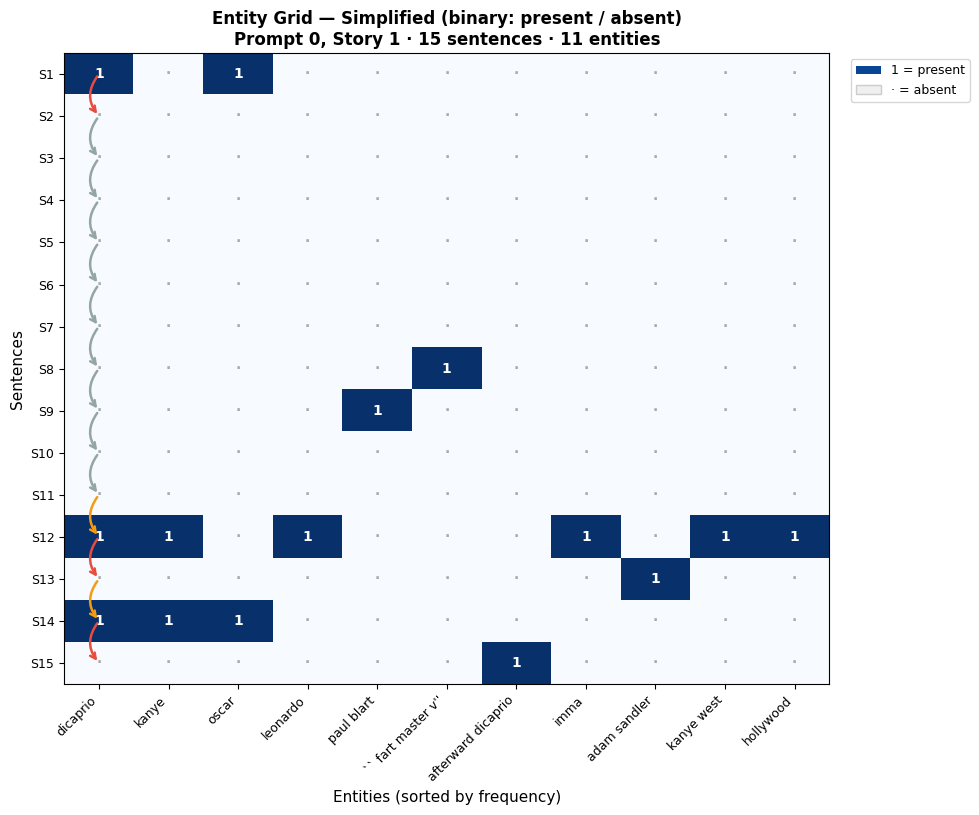


Transition profile for "dicaprio" (1st entity):
  0→0: 127x  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  0→1:  13x  ███████████████████████████████████████
  1→0:  14x  ██████████████████████████████████████████
  1→1:   0x  


In [12]:
# Example entity grid plot

from matplotlib.patches import Patch as _Patch

# Sort entities by frequency
entity_freq_ex = {e: sum(1 for se in sent_ents_ex if e in se) for e in all_ents_ex}
sorted_ents = sorted(all_ents_ex, key=lambda e: -entity_freq_ex[e])

# Limit display to max. 20 entities and 20 sentences
show_ents = sorted_ents[:20]
show_sents = min(len(sents_ex), 20)

# Build binary matrix: rows = sentences, columns = entities
grid_bin = np.zeros((show_sents, len(show_ents)), dtype=int)
for j, ent in enumerate(show_ents):
    for i in range(show_sents):
        grid_bin[i, j] = 1 if ent in sent_ents_ex[i] else 0

fig, ax = plt.subplots(figsize=(max(8, len(show_ents) * 0.9), show_sents * 0.45 + 1.5))
cmap_bin = plt.cm.Blues
ax.imshow(grid_bin, cmap=cmap_bin, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(show_ents)))
ax.set_xticklabels(show_ents, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(show_sents))
ax.set_yticklabels([f'S{i+1}' for i in range(show_sents)], fontsize=9)
ax.set_xlabel('Entities (sorted by frequency)', fontsize=11)
ax.set_ylabel('Sentences', fontsize=11)
ax.set_title('Entity Grid — Simplified (binary: present / absent)\n'
             f'Prompt 0, Story 1 · {show_sents} sentences · {len(show_ents)} entities',
             fontsize=12, fontweight='bold')

# Cell content: 1 / · 
for i in range(show_sents):
    for j in range(len(show_ents)):
        val = grid_bin[i, j]
        label = '1' if val == 1 else '·'
        color = 'white' if val == 1 else '#AAAAAA'
        ax.text(j, i, label, ha='center', va='center',
                fontsize=10, fontweight='bold', color=color)

legend_elements = [
    _Patch(facecolor='#084594', label='1 = present'),
    _Patch(facecolor='#F0F0F0', edgecolor='#CCCCCC', label='· = absent'),
]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(1.02, 1), fontsize=9)

# Transition annotation: highlight first entity
if len(show_ents) > 0 and show_sents > 1:
    ent0 = show_ents[0]
    presence0 = [grid_bin[i, 0] for i in range(show_sents)]
    for i in range(show_sents - 1):
        pair = (presence0[i], presence0[i + 1])
        colors = {(1, 1): '#27AE60', (1, 0): '#E74C3C',
                  (0, 1): '#F39C12', (0, 0): '#95A5A6'}
        ax.annotate('', xy=(0, i + 1), xytext=(0, i),
                    xycoords=('data', 'data'), textcoords=('data', 'data'),
                    arrowprops=dict(arrowstyle='->', color=colors[pair],
                                   lw=1.8, connectionstyle='arc3,rad=0.4'))

plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/entity_grid_simple_example.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nTransition profile for "{show_ents[0] if show_ents else "—"}" (1st entity):')
if show_ents:
    for tt in SIMPLE_TRANS_TYPES:
        lbl = f'{tt[0]}→{tt[1]}'
        n = trans_ex[tt]
        bar = '█' * int(n * 3)
        print(f'  {lbl}: {n:3d}x  {bar}')

In [13]:
# Computation for all prompts

disc_scores_simple = {}
t0 = time.time()

# Compute 4D vector (Sem, Lex, Syn, Disc) for all prompts
for source in SOURCES:
    scores = []
    for p in range(N_PROMPTS):
        scores.append(discourse_diversity_simple(texts[source][p]))
        if (p + 1) % 50 == 0:
            print(f'  {source:8s}: {p+1}/{N_PROMPTS} ({time.time()-t0:.0f}s)')
    disc_scores_simple[source] = np.array(scores)

print(f'\nDone in {time.time()-t0:.0f}s')

# Assemble 4D vector (Sem, Lex, Syn, Disc)
results_4d_simple = {}
for source in SOURCES:
    results_4d_simple[source] = np.column_stack([
        baseline_3d[source], disc_scores_simple[source]
    ])

print(f'\n4D vector (Simplified): (Sem, Lex, Syn, Disc)')
print(f'{"":<10}', end='')

for s in SOURCES: print(f'{s:>14}', end='')
print()
print('-' * 80)

for i, name in enumerate(METRIC_NAMES):
    print(f'{name:<10}', end='')
    for source in SOURCES:
        m = results_4d_simple[source][:, i].mean()
        s = results_4d_simple[source][:, i].std()
        print(f'{m:>8.4f}±{s:<5.3f}', end='')
    print()

  human   : 50/100 (59s)
  human   : 100/100 (112s)
  llama   : 50/100 (157s)
  llama   : 100/100 (200s)
  mistral : 50/100 (246s)
  mistral : 100/100 (291s)
  qwen    : 50/100 (326s)
  qwen    : 100/100 (361s)
  gemma   : 50/100 (393s)
  gemma   : 100/100 (426s)

Done in 426s

4D vector (Simplified): (Sem, Lex, Syn, Disc)
                   human         llama       mistral          qwen         gemma
--------------------------------------------------------------------------------
Sem         0.6664±0.070  0.3519±0.096  0.2866±0.094  0.3455±0.087  0.3432±0.084
Lex         0.9850±0.004  0.9365±0.018  0.9363±0.020  0.9592±0.013  0.9582±0.012
Syn         0.8046±0.016  0.6917±0.032  0.6713±0.024  0.7042±0.026  0.6847±0.026
Disc        0.0627±0.043  0.0581±0.043  0.0519±0.041  0.0559±0.042  0.0665±0.050


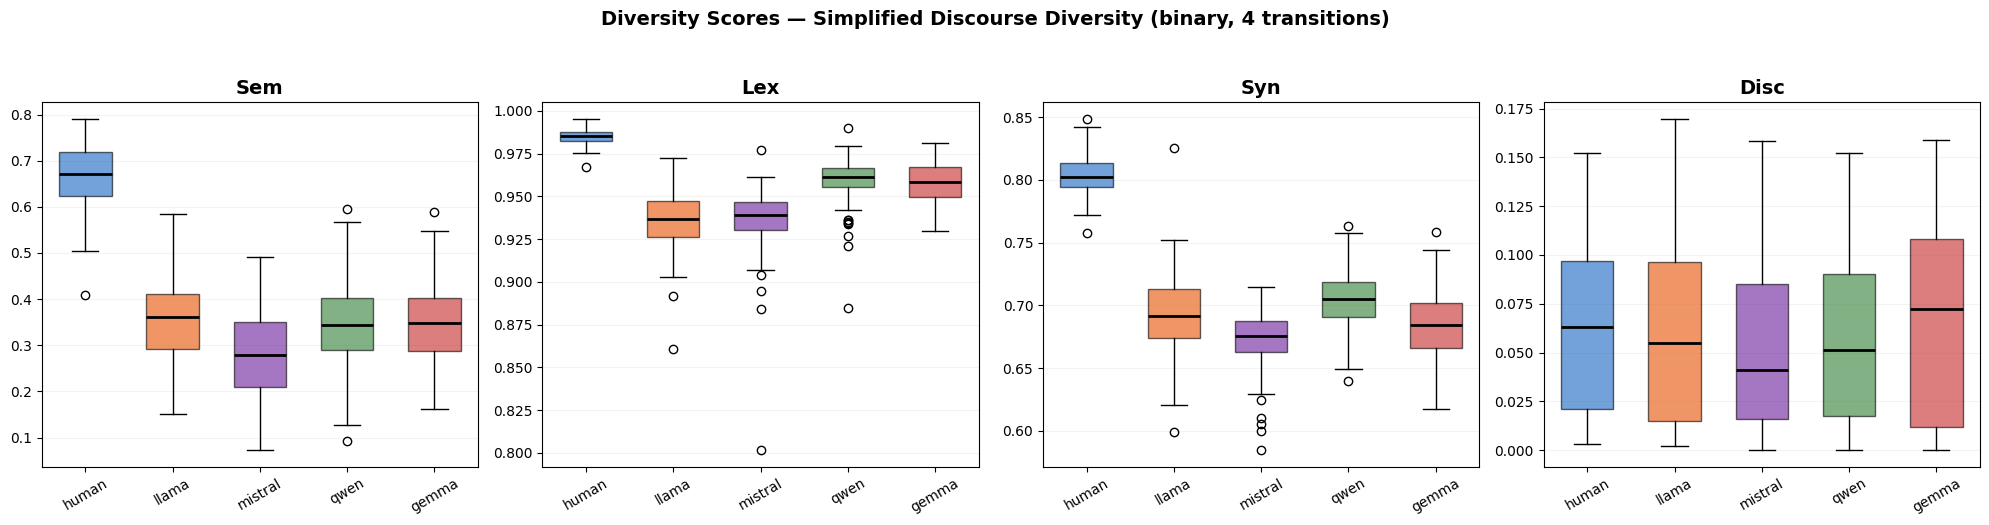

In [14]:
# Boxplots for each metric

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (name, ax) in enumerate(zip(METRIC_NAMES, axes)):
    data = [results_4d_simple[s][:, i] for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2), widths=0.6)
    for patch, source in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[source])
        patch.set_alpha(0.6)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')

fig.suptitle('Diversity Scores — Simplified Discourse Diversity (binary, 4 transitions)',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/boxplots_disc_div_simple.png', dpi=300, bbox_inches='tight')
plt.show()

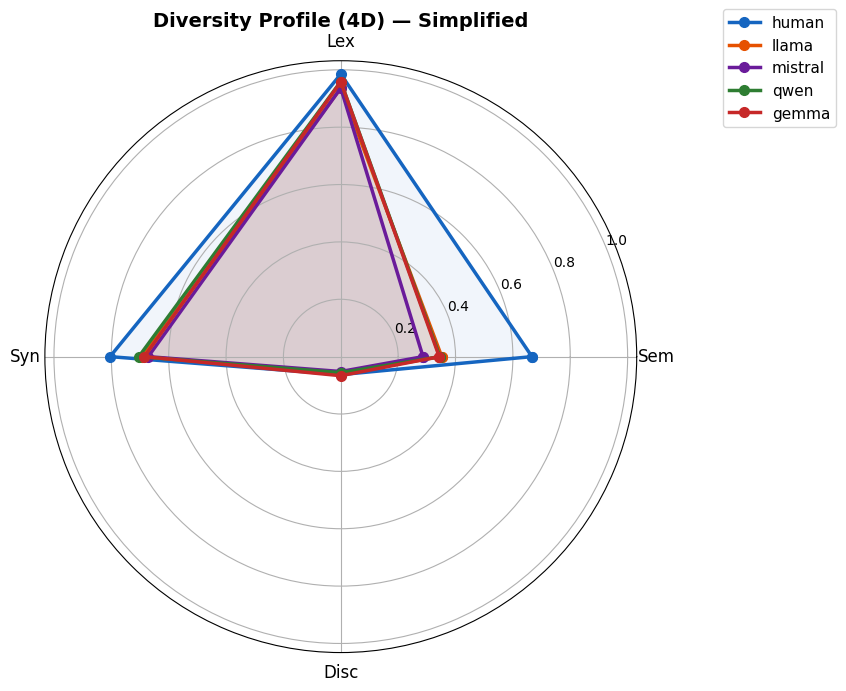

In [15]:
# Radar Chart

angles = np.linspace(0, 2 * np.pi, 4, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))
for source in SOURCES:
    means = results_4d_simple[source].mean(axis=0)
    values = means.tolist() + [means[0]]
    ax.plot(angles, values, 'o-', color=SOURCE_COLORS[source],
            linewidth=2.5, label=source, markersize=7)
    ax.fill(angles, values, alpha=0.06, color=SOURCE_COLORS[source])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
ax.set_title('Diversity Profile (4D) — Simplified',
             fontsize=14, fontweight='bold', pad=25)
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/radar_chart_disc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

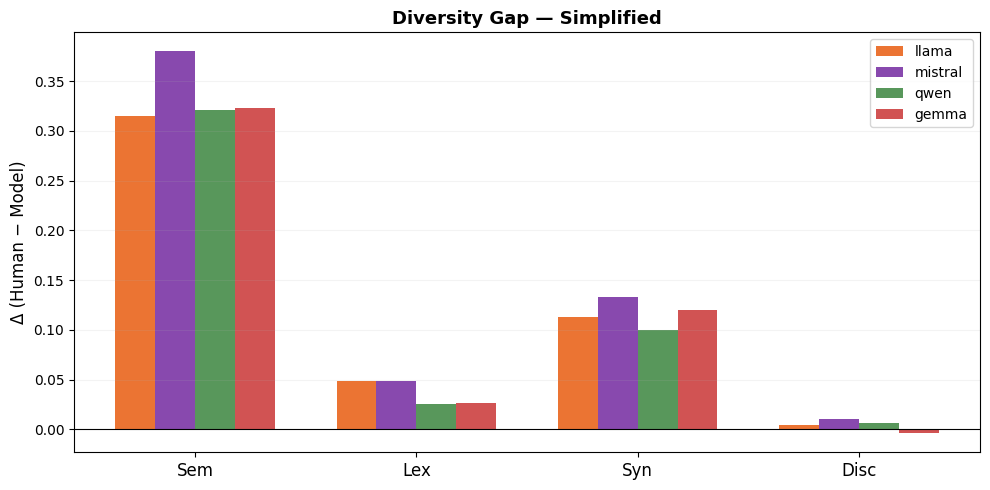

In [17]:
# Diversity Gap

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
width = 0.18
for j, source in enumerate(SOURCES[1:]):
    deltas = results_4d_simple['human'].mean(axis=0) - results_4d_simple[source].mean(axis=0)
    ax.bar(x + j*width, deltas, width, label=source,
           color=SOURCE_COLORS[source], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.set_ylabel('Δ (Human − Model)', fontsize=12)
ax.set_title('Diversity Gap — Simplified',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/diversity_gap_disc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Effect Size

print('Effect Size Human vs. Model — D_disc Simplified')
print(f'{"Model":<10} {"Cohen d":>10} {"Strength":>10} {"U-test p":>12}')
print('-' * 46)
h = disc_scores_simple['human']
for source in SOURCES[1:]:
    m = disc_scores_simple[source]
    d = cohens_d(h, m)
    _, p_val = mannwhitneyu(h, m, alternative='two-sided')
    strength = 'large' if abs(d) > 0.8 else 'medium' if abs(d) > 0.5 else 'small'
    print(f'{source:<10} {d:>+10.3f} {strength:>10} {p_val:>12.2e}')

Effect Size Human vs. Model — D_disc Simplified
Model         Cohen d   Strength     U-test p
----------------------------------------------
llama          +0.106      small     3.81e-01
mistral        +0.258      small     5.59e-02
qwen           +0.160      small     2.05e-01
gemma          -0.081      small     9.85e-01


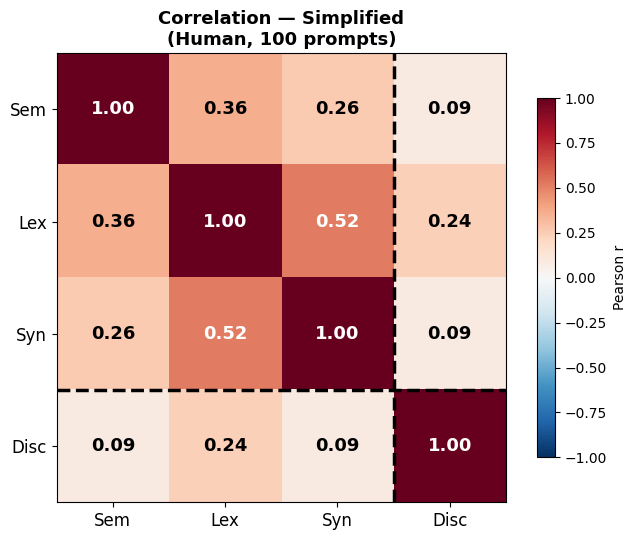

Correlations with D_disc (Simplified):
  Sem–Disc: r = +0.091 (weak)
  Lex–Disc: r = +0.241 (weak)
  Syn–Disc: r = +0.086 (weak)


In [19]:
# Correlation Analysis

corr_simple = np.corrcoef(results_4d_simple['human'].T)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr_simple, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.set_yticklabels(METRIC_NAMES, fontsize=12)
for i in range(4):
    for j in range(4):
        c = 'white' if abs(corr_simple[i,j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr_simple[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color=c, fontweight='bold')
ax.axhline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.axvline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.set_title('Correlation — Simplified\n(Human, 100 prompts)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/correlation_matrix_disc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

print('Correlations with D_disc (Simplified):')
for i, name in enumerate(METRIC_NAMES[:3]):
    r = corr_simple[i, 3]
    strength = 'strong' if abs(r) > 0.5 else 'moderate' if abs(r) > 0.3 else 'weak'
    print(f'  {name}–Disc: r = {r:+.3f} ({strength})')

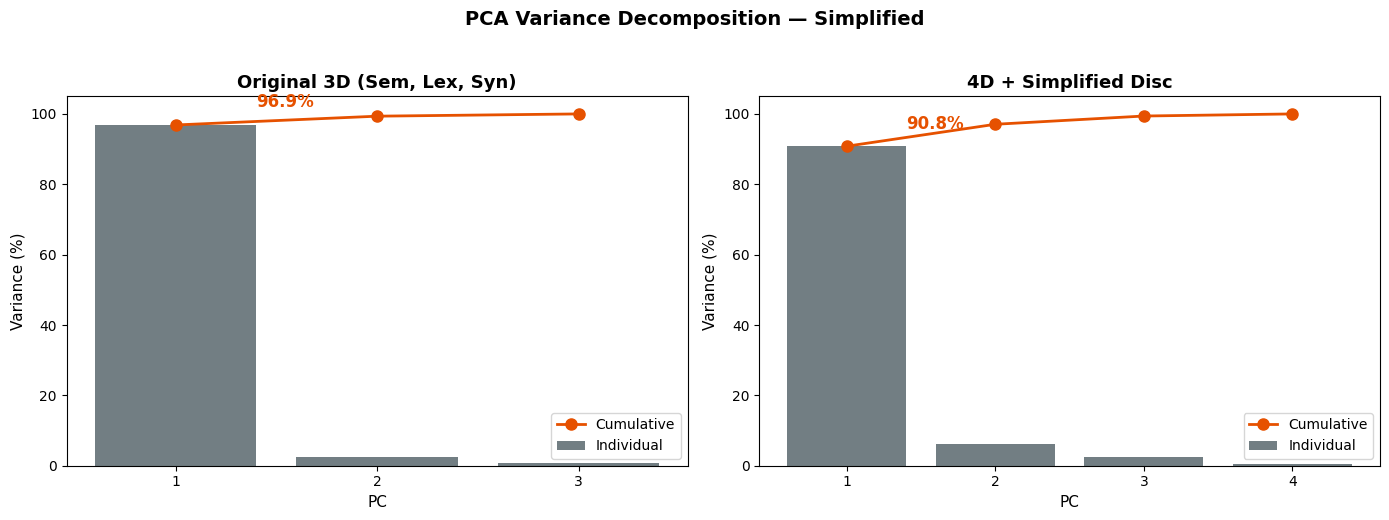

PC1: 3D = 96.9% → 4D = 90.8% (Drop: 6.0%)


In [21]:
# PCA: 3D vs 4D

all_4d_s = np.vstack([results_4d_simple[s] for s in SOURCES])
all_3d = all_4d_s[:, :3]

pca_3d = PCA().fit(all_3d)
pca_4d_simple = PCA().fit(all_4d_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pca_obj, title, n_dim in [
    (axes[0], pca_3d,        'Original 3D (Sem, Lex, Syn)', 3),
    (axes[1], pca_4d_simple, '4D + Simplified Disc', 4),
]:
    var = pca_obj.explained_variance_ratio_ * 100
    cum = np.cumsum(var)
    ax.bar(range(1, n_dim+1), var, color='#37474F', alpha=0.7, label='Individual')
    ax.plot(range(1, n_dim+1), cum, 'o-', color='#E65100', linewidth=2,
            markersize=8, label='Cumulative')
    ax.set_xlabel('PC', fontsize=11); ax.set_ylabel('Variance (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(range(1, n_dim+1))
    ax.legend(fontsize=10)
    ax.annotate(f'{var[0]:.1f}%', xy=(1, var[0]), xytext=(1.4, var[0]+5),
                fontsize=12, fontweight='bold', color='#E65100')
plt.suptitle('PCA Variance Decomposition — Simplified',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/pca_variance_disc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'PC1: 3D = {pca_3d.explained_variance_ratio_[0]:.1%} → '
      f'4D = {pca_4d_simple.explained_variance_ratio_[0]:.1%} '
      f'(Drop: {pca_3d.explained_variance_ratio_[0] - pca_4d_simple.explained_variance_ratio_[0]:.1%})')

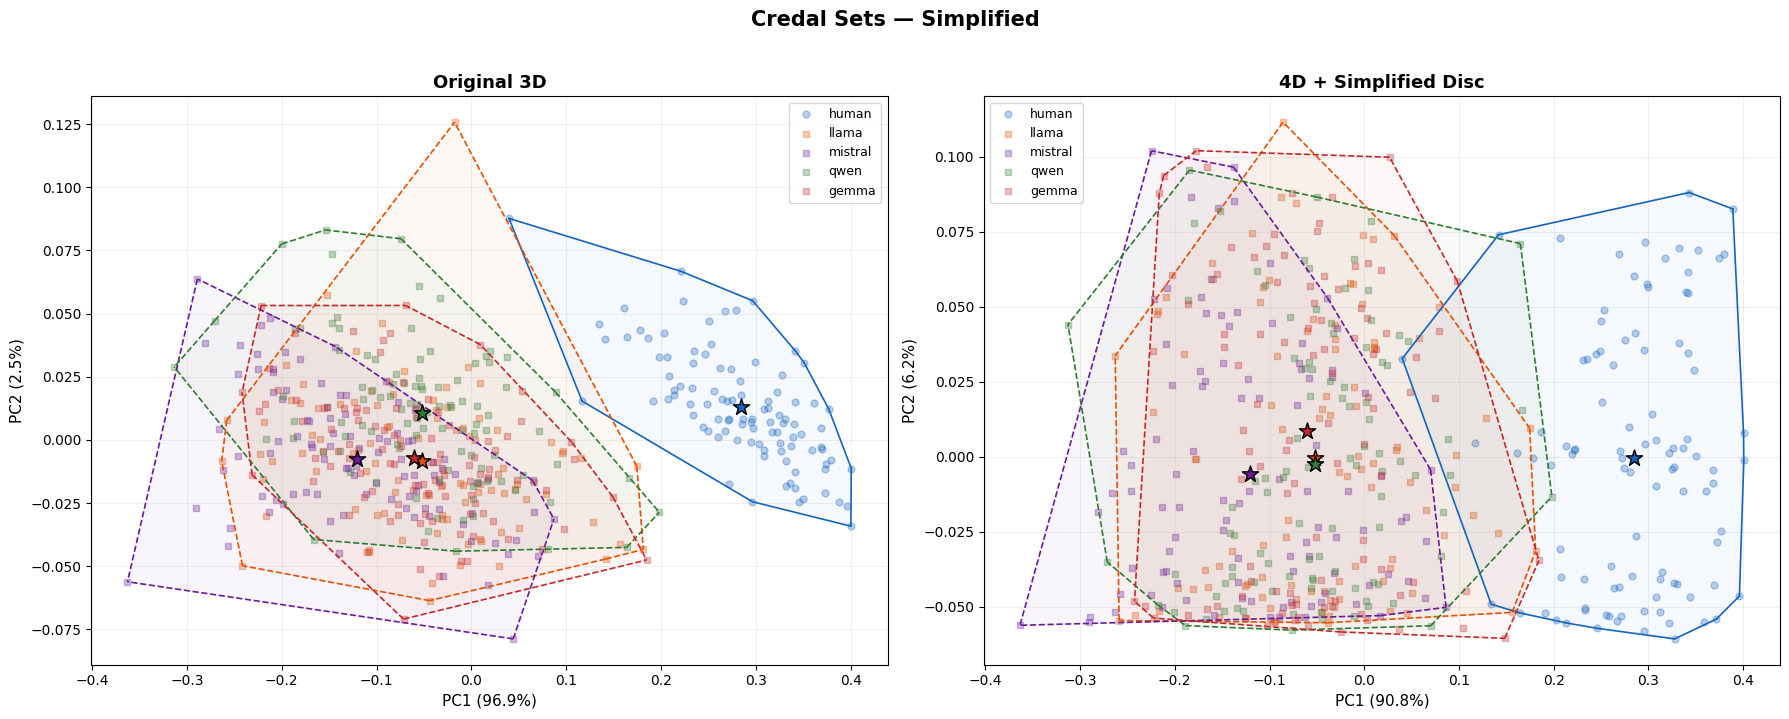

In [22]:
# Credal Sets: 3D vs 4D

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data_dict, title in [
    (axes[0], {s: results_4d_simple[s][:, :3] for s in SOURCES}, 'Original 3D'),
    (axes[1], results_4d_simple, '4D + Simplified Disc'),
]:
    all_data = np.vstack([data_dict[s] for s in SOURCES])
    pca_2d = PCA(n_components=2)
    all_pca = pca_2d.fit_transform(all_data)
    for i, source in enumerate(SOURCES):
        n = len(data_dict[source])
        pts = all_pca[i*n:(i+1)*n]
        marker = 'o' if source == 'human' else 's'
        ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source], alpha=0.3,
                  s=25, marker=marker, label=source)
        centroid = pts.mean(axis=0)
        ax.scatter(*centroid, c=SOURCE_COLORS[source], s=150, marker='*',
                  edgecolors='black', linewidth=1, zorder=5)
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ls = '-' if source == 'human' else '--'
                ax.plot(pts[simplex, 0], pts[simplex, 1],
                        color=SOURCE_COLORS[source], linewidth=1.2, linestyle=ls)
            poly = Polygon(pts[hull.vertices], alpha=0.04, color=SOURCE_COLORS[source])
            ax.add_patch(poly)
        except Exception:
            pass
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
plt.suptitle('Credal Sets — Simplified',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/credal_sets_disc_simple_4d.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Overlap-Koeffizienten

print('Overlap Human ↔ Model — Simplified')
print(f'{"Model":<10} {"3D":>8} {"4D":>8} {"Δ":>8}')
print('-' * 38)
for source in SOURCES[1:]:
    h = results_4d_simple['human']
    m = results_4d_simple[source]
    ov_3d = overlap_coefficient(h[:, :3], m[:, :3])
    ov_4d = overlap_coefficient(h, m)
    print(f'{source:<10} {ov_3d:>8.3f} {ov_4d:>8.3f} {ov_4d-ov_3d:>+8.3f}')

Overlap Human ↔ Model — Simplified
Model            3D       4D        Δ
--------------------------------------
llama         0.000    0.000   +0.000
mistral       0.000    0.000   +0.000
qwen          0.000    0.000   +0.000
gemma         0.000    0.000   +0.000


  human   : done (112s)
  llama   : done (199s)
  mistral : done (288s)
  qwen    : done (358s)
  gemma   : done (423s)


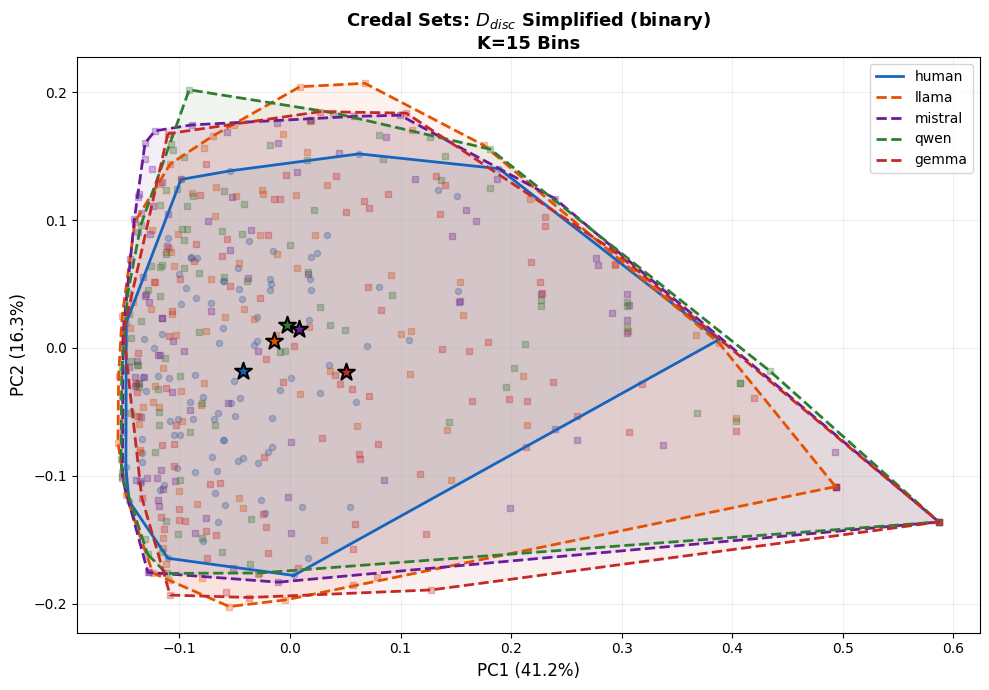

In [24]:
# Credal Sets: D_disc Simplified

K_BINS = 15
ALPHA_SMOOTH = 1.0
BIN_EDGES = np.linspace(0, 1, K_BINS + 1)

def pairwise_jsd_profiles_simple(texts_list):
    """Compute pairwise JSD of binary entity-grid profiles for a list of texts"""
    profiles = []

    # Compute entity-grid transitions for each text and convert to a profile
    for t in texts_list:
        trans, _, _ = entity_grid_transitions(t)
        total = sum(trans.values()) or 1
        profiles.append(np.array([trans[tt] / total for tt in SIMPLE_TRANS_TYPES]))

    # Compute pairwise JSD for all unique pairs of profiles
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.array([jsd(profiles[i], profiles[j]) for i, j in pairs])

raw_dists_simple = {}
t0 = time.time()

# Compute pairwise JSD profiles for all prompts and sources
for source in SOURCES:
    raw_dists_simple[source] = [
        pairwise_jsd_profiles_simple(texts[source][p]) for p in range(N_PROMPTS)
    ]
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')

# Transform raw distances to simplex points
all_raw_s = np.concatenate([np.concatenate(raw_dists_simple[s]) for s in SOURCES])
sorted_ref_s = np.sort(all_raw_s)

def rank_transform_s(values):
    """Rank-transform distances to [0, 1] based on reference distribution"""
    return np.searchsorted(sorted_ref_s, values, side='right') / len(sorted_ref_s)

def dist_to_simplex_s(distances):
    """Convert raw distances to a smoothed histogram (simplex point)"""
    # Rank-transform distances to [0, 1]
    ranked = rank_transform_s(distances)

    # Create histogram with smoothing
    counts, _ = np.histogram(ranked, bins=BIN_EDGES)

    # Add smoothing and normalize to get a point on the simplex
    smoothed = counts + ALPHA_SMOOTH
    return smoothed / smoothed.sum()

# Convert all raw distances to simplex points
simplex_simple = {
    s: np.array([dist_to_simplex_s(raw_dists_simple[s][p]) for p in range(N_PROMPTS)])
    for s in SOURCES
}

# Plot
all_sp = np.vstack([simplex_simple[s] for s in SOURCES])
pca_disc_s = PCA(n_components=2).fit(all_sp)
d2d_s = {s: pca_disc_s.transform(simplex_simple[s]) for s in SOURCES}

fig, ax = plt.subplots(figsize=(10, 7))
for source in SOURCES:
    pts = d2d_s[source]
    ls = '-' if source == 'human' else '--'
    marker = 'o' if source == 'human' else 's'
    ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source],
               alpha=0.3, s=20, marker=marker)
    centroid = pts.mean(axis=0)
    ax.scatter(*centroid, c=SOURCE_COLORS[source], s=160, marker='*',
               edgecolors='black', linewidth=1.5, zorder=6)
    try:
        hull = ConvexHull(pts)
        hull_idx = np.append(hull.vertices, hull.vertices[0])
        ax.fill(pts[hull.vertices, 0], pts[hull.vertices, 1],
                alpha=0.07, color=SOURCE_COLORS[source])
        ax.plot(pts[hull_idx, 0], pts[hull_idx, 1],
                color=SOURCE_COLORS[source], linewidth=2,
                linestyle=ls, label=source)
    except Exception:
        pass
ax.set_xlabel(f'PC1 ({pca_disc_s.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_disc_s.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Credal Sets: $D_{disc}$ Simplified (binary)\nK=15 Bins',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/credal_sets_disc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Full Entity Grid (Barzilay & Lapata, 2008)

Extension of the simplified model original Entity-Grid:

| Aspect | Part I (Simplified) | Part II (Full B&L) |
|---|---|---|
| Entity-Grid roles | binary: present (1) / absent (0) | **S**(ubject), **O**(bject), **X**(other), **–**(absent) |
| Transition types | 4 ($2^2$) | **16** ($4^2$) bigram + **64** ($4^3$) trigram |
| Role assignment | — | **Dependency Parsing** (spaCy) |
| Entity weighting | all equal | **Salience**: $w_e = \log(1 + \text{freq}(e))$ |
| Entity filter | none | $\text{freq}(e) \geq 2$* |
| Sentence tokenizer | Regex | **spaCy sentencizer** + abbreviation protection |

*see Section 4 for detailed analysis of frequency filter

### Grammatical Roles

| Role | Abbreviation | Dependency Labels (spaCy) |
|---|---|---|
| Subject | **S** | `nsubj`, `nsubjpass`, `csubj` |
| Object | **O** | `dobj`, `iobj`, `pobj`, `attr`, `oprd` |
| Other | **X** | all other grammatical relations |
| Absent | **–** | entity does not appear in the sentence |

$D_{\text{disc}}^{\text{full}} = (1 - \alpha) \cdot \text{JSD}_{\text{bigram}} + \alpha \cdot \text{JSD}_{\text{trigram}}, \quad \alpha = 0.3$

In [25]:
# D_disc: Complete Entity-Grid Model

ROLES = ['S', 'O', 'X', '-']
ROLE_S, ROLE_O, ROLE_X, ROLE_ABSENT = 'S', 'O', 'X', '-'
BIGRAM_TRANSITIONS = [(r1, r2) for r1 in ROLES for r2 in ROLES]  # 16
TRIGRAM_TRANSITIONS = [(r1, r2, r3) for r1 in ROLES for r2 in ROLES for r3 in ROLES]  # 64
N_BIGRAM = len(BIGRAM_TRANSITIONS)
N_TRIGRAM = len(TRIGRAM_TRANSITIONS)
MIN_ENTITY_FREQ = 2

# Improved Sentence Tokenizer
def sent_tokenize_full(text):
    """spaCy sentencizer"""
    doc = nlp(text)
    sents = [sent.text.strip() for sent in doc.sents]
    
    return [s for s in sents if len(s.strip()) > 5]


# Grammatical Roles
_SUBJ_DEPS = {'nsubj', 'nsubjpass', 'csubj', 'csubjpass'}
_OBJ_DEPS = {'dobj', 'iobj', 'pobj', 'attr', 'oprd', 'dative'}
_VALID_NER = {'PERSON', 'ORG', 'GPE', 'LOC', 'PRODUCT', 'EVENT',
              'WORK_OF_ART', 'FAC', 'NORP'}


# Determine role for a token based on its dependency relation and head
def _get_role_for_token(token):
    if token.dep_ in _SUBJ_DEPS:
        return ROLE_S
    if token.dep_ in _OBJ_DEPS:
        return ROLE_O
    if token.head != token:
        if token.head.dep_ in _SUBJ_DEPS:
            return ROLE_S
        if token.head.dep_ in _OBJ_DEPS:
            return ROLE_O
    return ROLE_X


def extract_entity_roles_spacy(sent_doc):
    """Entities + grammatical roles via spaCy. Priority: S > O > X"""
    entity_roles = {}
    role_priority = {ROLE_S: 3, ROLE_O: 2, ROLE_X: 1}

    # Extract entities and determine their roles based on dependency parsing
    for ent in sent_doc.ents:
        if ent.label_ not in _VALID_NER:
            continue
        
        # Normalize entity name
        name = ent.text.lower().strip()
        if len(name) < 2:
            continue

        role = ROLE_X

        # Check all tokens in the entity span to determine the highest-priority role
        for token in ent:
            token_role = _get_role_for_token(token)
            if role_priority.get(token_role, 0) > role_priority.get(role, 0):
                role = token_role
    
        # Update entity role if it's the first occurrence or if the new role has higher priority
        if name not in entity_roles or \
           role_priority[role] > role_priority[entity_roles[name]]:
            entity_roles[name] = role

    return entity_roles



def build_entity_grid_full(text):
    """Full entity grid with S/O/X/– roles and frequency filtering"""
    sents = sent_tokenize_full(text)

    # If fewer than 2 sentences, return empty grid and frequencies
    if len(sents) < 2:
        return {}, sents, {}
    
    sent_entity_roles = []

    # Extract entities and their roles for all sentences in a single batch
    docs = list(nlp.pipe(sents, batch_size=50))
    for doc in docs:
        sent_entity_roles.append(extract_entity_roles_spacy(doc))
    
    # Collect all unique entities across sentences
    all_entities = set()
    for roles in sent_entity_roles:
        all_entities.update(roles.keys())

    if not all_entities:
        return {}, sents, {}
    
    # Build the entity grid and count frequencies
    grid = {}
    entity_freq = {}
    for entity in all_entities:
        roles_seq = []
        freq = 0

        # For each sentence, determine the role of the entity (or absence)
        for sent_roles in sent_entity_roles:
            if entity in sent_roles:
                roles_seq.append(sent_roles[entity])
                freq += 1

            else:
                roles_seq.append(ROLE_ABSENT)

        grid[entity] = roles_seq
        entity_freq[entity] = freq

    return grid, sents, entity_freq


def compute_transition_profile_full(text, use_trigrams=True):
    """Weighted bigram+trigram profile based on entity grid with frequency filtering"""
    grid, sents, entity_freq = build_entity_grid_full(text)

    # If no valid grid or fewer than 2 sentences, return uniform profiles and empty grid/frequencies
    if not grid or len(sents) < 2:
        return (np.ones(N_BIGRAM) / N_BIGRAM,
                np.ones(N_TRIGRAM) / N_TRIGRAM if use_trigrams else None, grid, sents, entity_freq)
    
    # Count bigram and trigram transitions, weighted by log(1 + frequency)
    bigram_counts = Counter()
    trigram_counts = Counter()
    for entity, roles_seq in grid.items():

        # Filter out low-frequency entities
        if entity_freq[entity] < MIN_ENTITY_FREQ:
            continue
        weight = np.log(1 + entity_freq[entity])

        # Bigram transitions
        for k in range(len(roles_seq) - 1):
            bigram_counts[(roles_seq[k], roles_seq[k+1])] += weight

        # Trigram transitions
        if use_trigrams and len(roles_seq) >= 3:
            for k in range(len(roles_seq) - 2):
                trigram_counts[(roles_seq[k], roles_seq[k+1], roles_seq[k+2])] += weight

    # Normalize to get profiles
    bigram_total = sum(bigram_counts.values()) or 1
    bigram_profile = np.array([bigram_counts[t] / bigram_total for t in BIGRAM_TRANSITIONS])
    trigram_profile = None

    if use_trigrams:
        trigram_total = sum(trigram_counts.values()) or 1
        trigram_profile = np.array([trigram_counts[t] / trigram_total for t in TRIGRAM_TRANSITIONS])

    return bigram_profile, trigram_profile, grid, sents, entity_freq


def discourse_diversity_full(texts_list, use_trigrams=True, alpha_trigram=0.3):
    """Full B&L D_disc: (1-α)·JSD_bigram + α·JSD_trigram"""
    profiles_bi, profiles_tri = [], []

    # Compute profiles for all texts
    for t in texts_list:
        bi, tri, _, _, _ = compute_transition_profile_full(t, use_trigrams=use_trigrams)
        profiles_bi.append(bi)

        if tri is not None:
            profiles_tri.append(tri)
    
    # Compute pairwise JSD for bigram profiles
    profiles_bi = np.array(profiles_bi)
    pairs = list(combinations(range(len(texts_list)), 2))
    jsd_bi = np.mean([jsd(profiles_bi[i], profiles_bi[j]) for i, j in pairs])

    # Compute pairwise JSD for trigram profiles if available
    if use_trigrams and profiles_tri:
        profiles_tri = np.array(profiles_tri)
        jsd_tri = np.mean([jsd(profiles_tri[i], profiles_tri[j]) for i, j in pairs])
        return (1 - alpha_trigram) * jsd_bi + alpha_trigram * jsd_tri
    
    return jsd_bi


print(f'  Full B&L implemented')
print(f'  Roles: {ROLES}')
print(f'  {N_BIGRAM} bigram + {N_TRIGRAM} trigram transitions')
print(f'  Entity filter: freq ≥ {MIN_ENTITY_FREQ}, weighting: log(1 + freq)')
print('  Dep-Parsing: spaCy')

  Full B&L implemented
  Roles: ['S', 'O', 'X', '-']
  16 bigram + 64 trigram transitions
  Entity filter: freq ≥ 2, weighting: log(1 + freq)
  Dep-Parsing: spaCy


Example: Prompt 0, Story 1
17 sentences, 12 entities (3 after freq filter)

Top Entities:
  dicaprio                  freq= 3  w=1.39
  kanye                     freq= 2  w=1.10
  oscar                     freq= 2  w=1.10

Bigram transitions (top 8 / 16):
  -→-: 0.745 ███████████████████████████████████████████████████████████
  O→-: 0.106 ████████
  -→O: 0.082 ██████
  S→-: 0.043 ███
  -→S: 0.024 █
  S→S: 0.000 
  S→O: 0.000 
  S→X: 0.000 

Trigram transitions (top 6 / 64):
  -→-→-: 0.728 ██████████████████████████████████████████████████████████
  -→O→-: 0.087 ██████
  -→-→O: 0.067 █████
  O→-→S: 0.026 ██
  O→-→-: 0.026 ██
  -→S→-: 0.026 ██


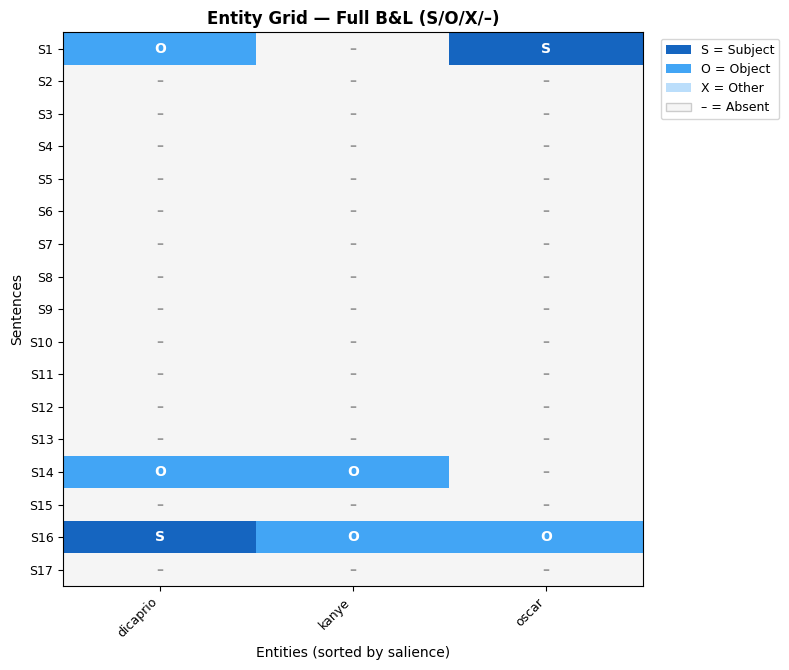

In [27]:
# Example: Entity Grid with S/O/X/– roles

bi_prof, tri_prof, grid_f, sents_f, entity_freq = compute_transition_profile_full(example_story)
filtered = {e: f for e, f in entity_freq.items() if f >= MIN_ENTITY_FREQ}

print(f'Example: Prompt 0, Story 1')
print(f'{len(sents_f)} sentences, {len(grid_f)} entities ({len(filtered)} after freq filter)')
print(f'\nTop Entities:')
for ent, freq in sorted(filtered.items(), key=lambda x: -x[1])[:8]:
    print(f'  {ent:25s} freq={freq:2d}  w={np.log(1+freq):.2f}')

print(f'\nBigram transitions (top 8 / {N_BIGRAM}):')
sorted_bi = sorted(zip(BIGRAM_TRANSITIONS, bi_prof), key=lambda x: -x[1])
for trans, prob in sorted_bi[:8]:
    bar = '█' * int(prob * 80)
    print(f'  {trans[0]}→{trans[1]}: {prob:.3f} {bar}')

if tri_prof is not None:
    print(f'\nTrigram transitions (top 6 / {N_TRIGRAM}):')
    sorted_tri = sorted(zip(TRIGRAM_TRANSITIONS, tri_prof), key=lambda x: -x[1])
    for trans, prob in sorted_tri[:6]:
        bar = '█' * int(prob * 80)
        print(f'  {trans[0]}→{trans[1]}→{trans[2]}: {prob:.3f} {bar}')

# Heatmap
if filtered:
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch
    show_ents = sorted(filtered.keys(), key=lambda e: -entity_freq[e])[:15]
    show_sents = min(len(sents_f), 20)
    role_to_num = {ROLE_S: 3, ROLE_O: 2, ROLE_X: 1, ROLE_ABSENT: 0}
    role_to_label = {ROLE_S: 'S', ROLE_O: 'O', ROLE_X: 'X', ROLE_ABSENT: '–'}
    grid_num = np.zeros((show_sents, len(show_ents)))
    for j, ent in enumerate(show_ents):
        for i in range(show_sents):
            grid_num[i, j] = role_to_num[grid_f[ent][i]]
    cmap = ListedColormap(['#F5F5F5', '#BBDEFB', '#42A5F5', '#1565C0'])
    fig, ax = plt.subplots(figsize=(max(8, len(show_ents)*0.9), show_sents*0.4))
    ax.imshow(grid_num, cmap=cmap, aspect='auto', vmin=0, vmax=3)
    ax.set_xticks(range(len(show_ents)))
    ax.set_xticklabels(show_ents, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(show_sents))
    ax.set_yticklabels([f'S{i+1}' for i in range(show_sents)], fontsize=9)
    ax.set_xlabel('Entities (sorted by salience)')
    ax.set_ylabel('Sentences')
    ax.set_title('Entity Grid — Full B&L (S/O/X/–)', fontsize=12, fontweight='bold')
    for i in range(show_sents):
        for j in range(len(show_ents)):
            role = grid_f[show_ents[j]][i]
            label = role_to_label[role]
            color = 'white' if role in (ROLE_S, ROLE_O) else '#999999'
            ax.text(j, i, label, ha='center', va='center',
                   fontsize=10, fontweight='bold', color=color)
    legend_elements = [
        Patch(facecolor='#1565C0', label='S = Subject'),
        Patch(facecolor='#42A5F5', label='O = Object'),
        Patch(facecolor='#BBDEFB', label='X = Other'),
        Patch(facecolor='#F5F5F5', edgecolor='#CCCCCC', label='– = Absent'),
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              bbox_to_anchor=(1.02, 1), fontsize=9)
    plt.tight_layout()
    plt.savefig('../../figures/discourse_diversity/entity_grid_full_example.png', dpi=300, bbox_inches='tight')
    plt.show()

In [28]:
# Computation over all prompts

disc_scores_full = {}
t0 = time.time()

# Compute D_disc for all prompts using the full entity-grid model with bigram+trigram profiles
for source in SOURCES:
    scores = []

    for p in range(N_PROMPTS):
        scores.append(discourse_diversity_full(texts[source][p],
                                               use_trigrams=True, alpha_trigram=0.3))
        
        # Progress update every 25 prompts
        if (p + 1) % 25 == 0:
            print(f'  {source:8s}: {p+1}/{N_PROMPTS} ({time.time()-t0:.0f}s)')

    disc_scores_full[source] = np.array(scores)

print(f'\nDone in {time.time()-t0:.0f}s')

# Assemble 4D vector (Sem, Lex, Syn, Disc) for the full model
results_4d_full = {}
for source in SOURCES:
    results_4d_full[source] = np.column_stack([
        baseline_3d[source], disc_scores_full[source]
    ])

print(f'\n4D vector (Full B&L): (Sem, Lex, Syn, Disc)')
print(f'{"":<10}', end='')
for s in SOURCES: print(f'{s:>14}', end='')
print()
print('-' * 80)
for i, name in enumerate(METRIC_NAMES):
    print(f'{name:<10}', end='')
    for source in SOURCES:
        m = results_4d_full[source][:, i].mean()
        s = results_4d_full[source][:, i].std()
        print(f'{m:>8.4f}±{s:<5.3f}', end='')
    print()

  human   : 25/100 (34s)
  human   : 50/100 (67s)
  human   : 75/100 (99s)
  human   : 100/100 (129s)
  llama   : 25/100 (156s)
  llama   : 50/100 (184s)
  llama   : 75/100 (210s)
  llama   : 100/100 (238s)
  mistral : 25/100 (268s)
  mistral : 50/100 (296s)
  mistral : 75/100 (325s)
  mistral : 100/100 (352s)
  qwen    : 25/100 (374s)
  qwen    : 50/100 (395s)
  qwen    : 75/100 (417s)
  qwen    : 100/100 (438s)
  gemma   : 25/100 (458s)
  gemma   : 50/100 (477s)
  gemma   : 75/100 (497s)
  gemma   : 100/100 (516s)

Done in 516s

4D vector (Full B&L): (Sem, Lex, Syn, Disc)
                   human         llama       mistral          qwen         gemma
--------------------------------------------------------------------------------
Sem         0.6664±0.070  0.3519±0.096  0.2866±0.094  0.3455±0.087  0.3432±0.084
Lex         0.9850±0.004  0.9365±0.018  0.9363±0.020  0.9592±0.013  0.9582±0.012
Syn         0.8046±0.016  0.6917±0.032  0.6713±0.024  0.7042±0.026  0.6847±0.026
Disc        0.

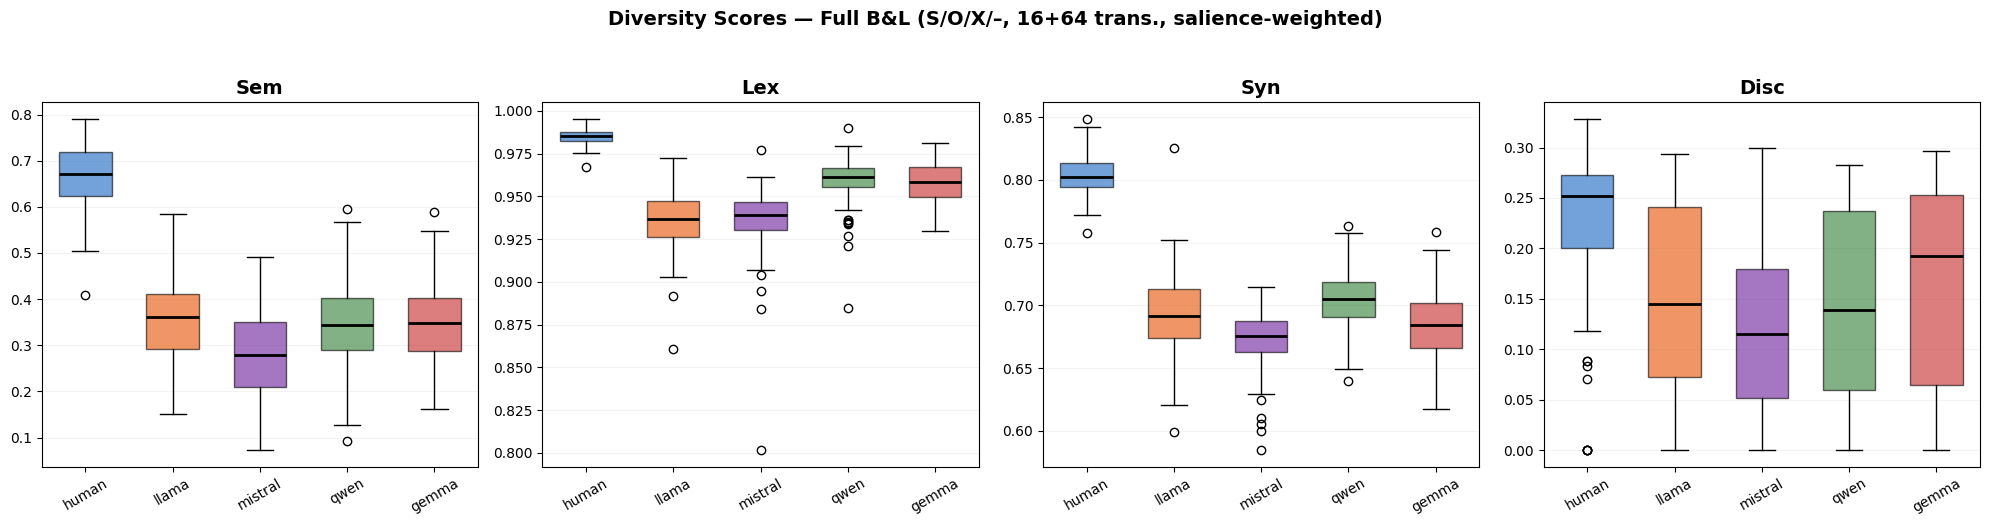

In [29]:
# Boxplot

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (name, ax) in enumerate(zip(METRIC_NAMES, axes)):
    data = [results_4d_full[s][:, i] for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2), widths=0.6)
    for patch, source in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[source])
        patch.set_alpha(0.6)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')

fig.suptitle('Diversity Scores — Full B&L (S/O/X/–, 16+64 trans., salience-weighted)',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/diversity_scores_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()

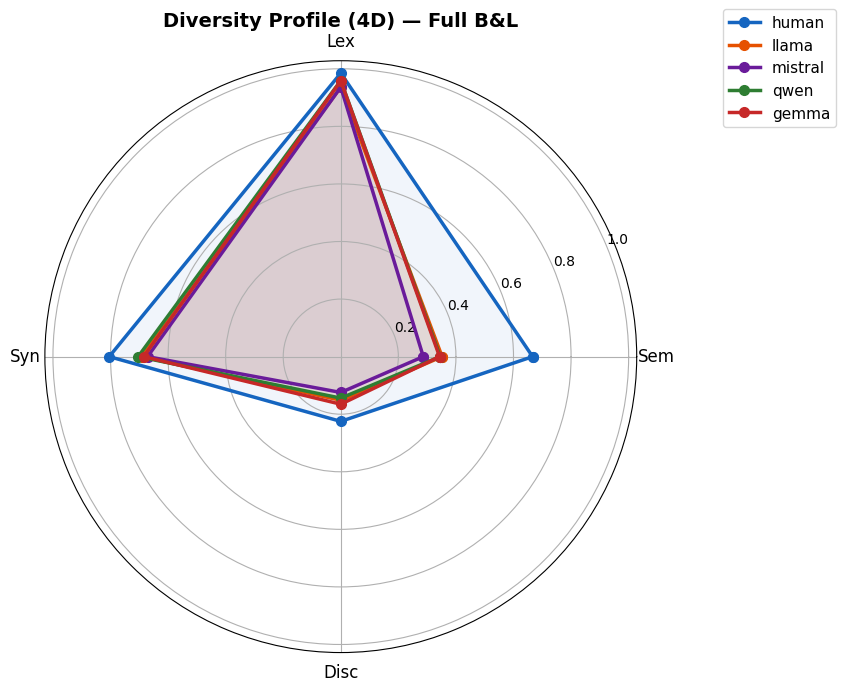

In [30]:
# Radar Chart

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))
for source in SOURCES:
    means = results_4d_full[source].mean(axis=0)
    values = means.tolist() + [means[0]]
    ax.plot(angles, values, 'o-', color=SOURCE_COLORS[source],
            linewidth=2.5, label=source, markersize=7)
    ax.fill(angles, values, alpha=0.06, color=SOURCE_COLORS[source])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
ax.set_title('Diversity Profile (4D) — Full B&L',
             fontsize=14, fontweight='bold', pad=25)
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/radar_chart_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()

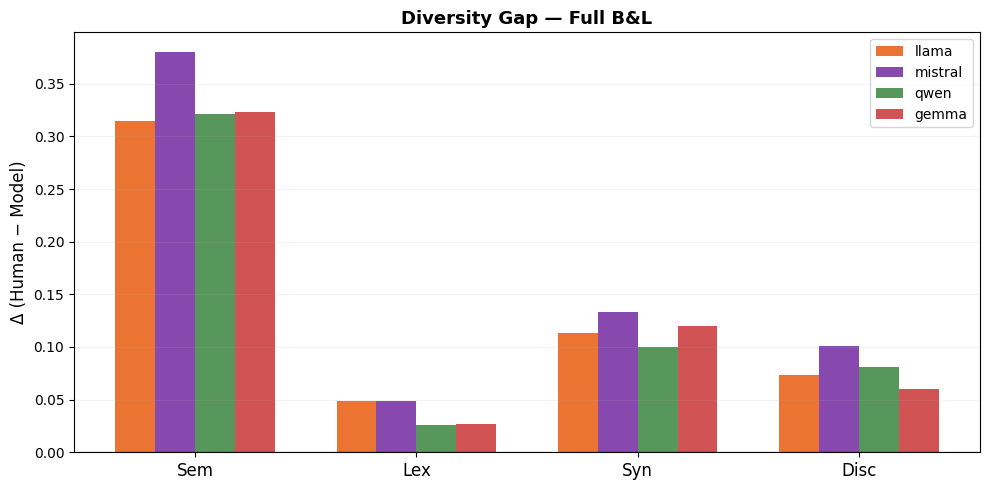

In [32]:
# Diversity Gap

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
width = 0.18
for j, source in enumerate(SOURCES[1:]):
    deltas = results_4d_full['human'].mean(axis=0) - results_4d_full[source].mean(axis=0)
    ax.bar(x + j*width, deltas, width, label=source,
           color=SOURCE_COLORS[source], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.set_ylabel('Δ (Human − Model)', fontsize=12)
ax.set_title('Diversity Gap — Full B&L',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/diversity_gap_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# Effect Size

print('Effect Size Human vs. Model — D_disc Full B&L')
print(f'{"Model":<10} {"Cohen d":>10} {"Strength":>10} {"U-test p":>12}')
print('-' * 46)
h = disc_scores_full['human']
for source in SOURCES[1:]:
    m = disc_scores_full[source]
    d = cohens_d(h, m)
    _, p_val = mannwhitneyu(h, m, alternative='two-sided')
    strength = 'large' if abs(d) > 0.8 else 'medium' if abs(d) > 0.5 else 'small'
    print(f'{source:<10} {d:>+10.3f} {strength:>10} {p_val:>12.2e}')

Effect Size Human vs. Model — D_disc Full B&L
Model         Cohen d   Strength     U-test p
----------------------------------------------
llama          +0.920      large     5.19e-09
mistral        +1.301      large     2.04e-14
qwen           +0.983      large     7.31e-11
gemma          +0.706     medium     5.86e-06


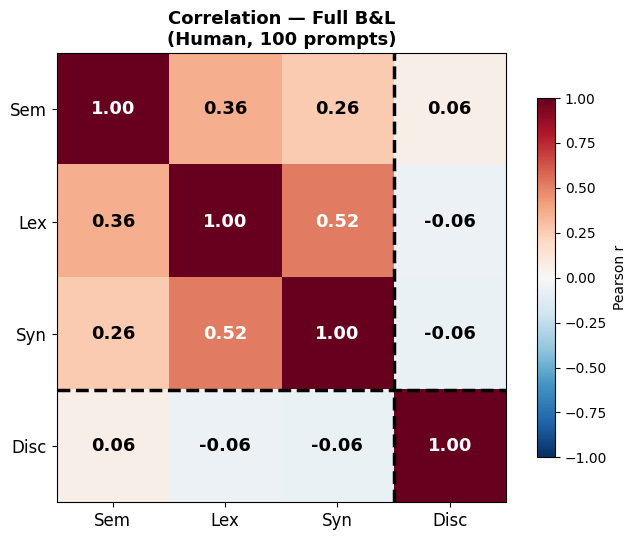

Correlations with D_disc (Full B&L):
  Sem–Disc: r = +0.056 (weak)
  Lex–Disc: r = -0.062 (weak)
  Syn–Disc: r = -0.065 (weak)


In [34]:
# ── Correlation Analysis ──

corr_full = np.corrcoef(results_4d_full['human'].T)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr_full, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.set_yticklabels(METRIC_NAMES, fontsize=12)
for i in range(4):
    for j in range(4):
        c = 'white' if abs(corr_full[i,j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr_full[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color=c, fontweight='bold')
ax.axhline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.axvline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.set_title('Correlation — Full B&L\n(Human, 100 prompts)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/correlation_matrix_disc_full.png', dpi=300, bbox_inches='tight')   
plt.show()

print('Correlations with D_disc (Full B&L):')
for i, name in enumerate(METRIC_NAMES[:3]):
    r = corr_full[i, 3]
    strength = 'strong' if abs(r) > 0.5 else 'moderate' if abs(r) > 0.3 else 'weak'
    print(f'  {name}–Disc: r = {r:+.3f} ({strength})')

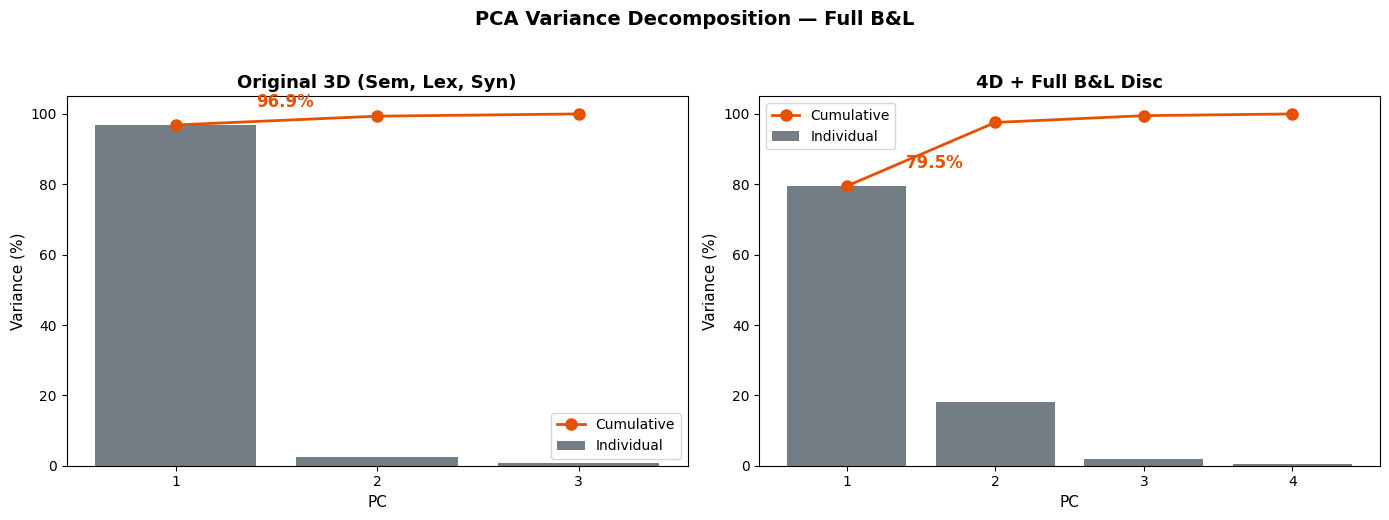

PC1: 3D = 96.9% → 4D = 79.5% (Drop: 17.4%)


In [35]:
# ── PCA: 3D vs 4D ──

all_4d_f = np.vstack([results_4d_full[s] for s in SOURCES])
pca_4d_full = PCA().fit(all_4d_f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pca_obj, title, n_dim in [
    (axes[0], pca_3d,      'Original 3D (Sem, Lex, Syn)', 3),
    (axes[1], pca_4d_full, '4D + Full B&L Disc', 4),
]:
    var = pca_obj.explained_variance_ratio_ * 100
    cum = np.cumsum(var)
    ax.bar(range(1, n_dim+1), var, color='#37474F', alpha=0.7, label='Individual')
    ax.plot(range(1, n_dim+1), cum, 'o-', color='#E65100', linewidth=2,
            markersize=8, label='Cumulative')
    ax.set_xlabel('PC', fontsize=11); ax.set_ylabel('Variance (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(range(1, n_dim+1))
    ax.legend(fontsize=10)
    ax.annotate(f'{var[0]:.1f}%', xy=(1, var[0]), xytext=(1.4, var[0]+5),
                fontsize=12, fontweight='bold', color='#E65100')
plt.suptitle('PCA Variance Decomposition — Full B&L',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/pca_variance_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'PC1: 3D = {pca_3d.explained_variance_ratio_[0]:.1%} → '
      f'4D = {pca_4d_full.explained_variance_ratio_[0]:.1%} '
      f'(Drop: {pca_3d.explained_variance_ratio_[0] - pca_4d_full.explained_variance_ratio_[0]:.1%})')

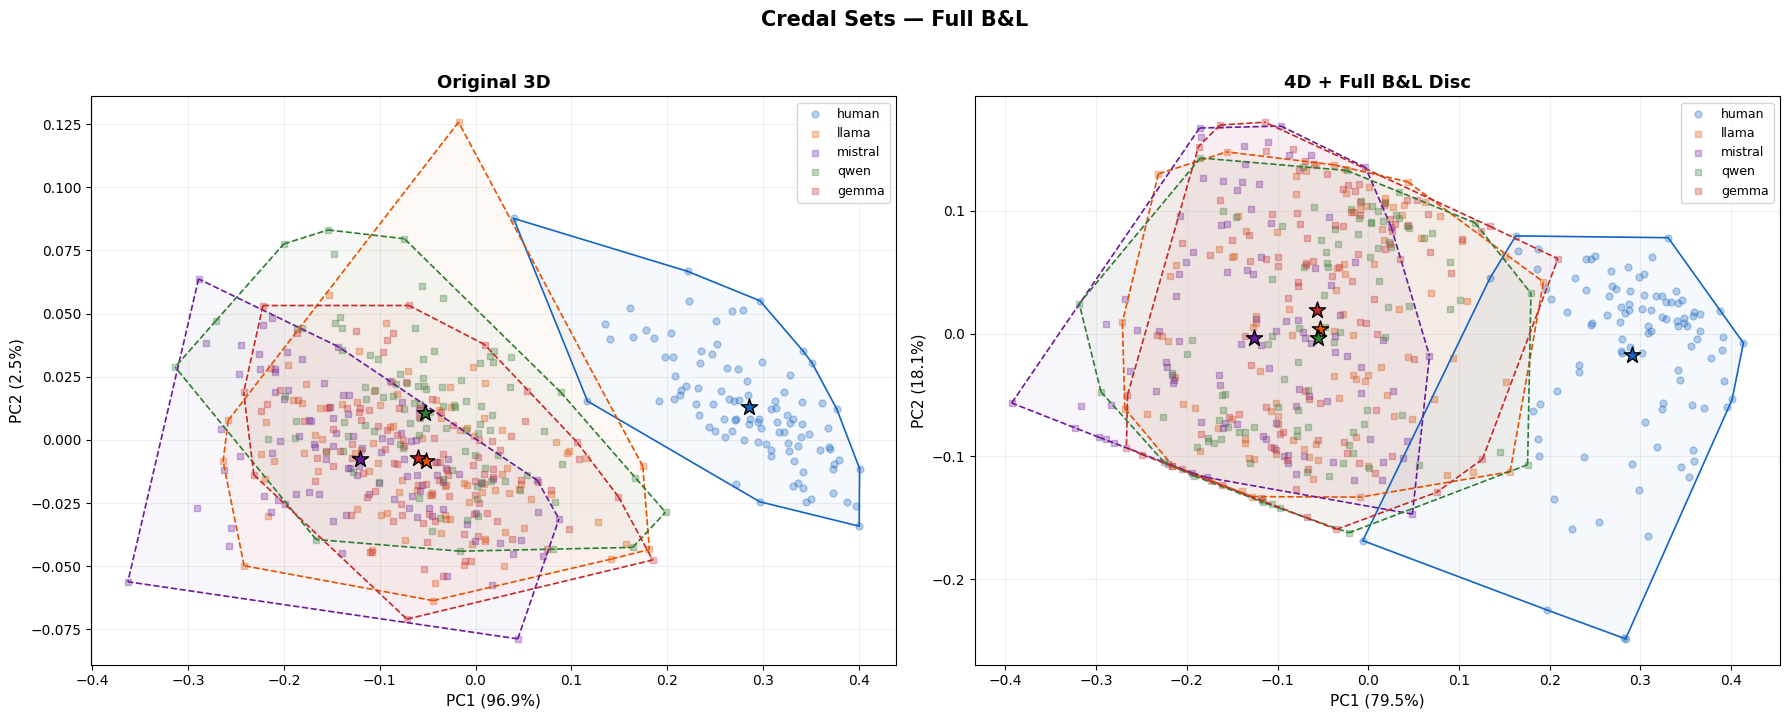

In [36]:
# Credal Sets: 3D vs 4D

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data_dict, title in [
    (axes[0], {s: results_4d_full[s][:, :3] for s in SOURCES}, 'Original 3D'),
    (axes[1], results_4d_full, '4D + Full B&L Disc'),
]:
    all_data = np.vstack([data_dict[s] for s in SOURCES])
    pca_2d = PCA(n_components=2)
    all_pca = pca_2d.fit_transform(all_data)
    for i, source in enumerate(SOURCES):
        n = len(data_dict[source])
        pts = all_pca[i*n:(i+1)*n]
        marker = 'o' if source == 'human' else 's'
        ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source], alpha=0.3,
                  s=25, marker=marker, label=source)
        centroid = pts.mean(axis=0)
        ax.scatter(*centroid, c=SOURCE_COLORS[source], s=150, marker='*',
                  edgecolors='black', linewidth=1, zorder=5)
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ls = '-' if source == 'human' else '--'
                ax.plot(pts[simplex, 0], pts[simplex, 1],
                        color=SOURCE_COLORS[source], linewidth=1.2, linestyle=ls)
            poly = Polygon(pts[hull.vertices], alpha=0.04, color=SOURCE_COLORS[source])
            ax.add_patch(poly)
        except Exception:
            pass
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
plt.suptitle('Credal Sets — Full B&L',
             fontsize=15, fontweight='bold', y=1.02)
plt.savefig('../../figures/discourse_diversity/credal_sets_disc_full_4d.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [37]:
# Overlap-Koeffizienten

print('Overlap Human ↔ Model — Full B&L')
print(f'{"Model":<10} {"3D":>8} {"4D":>8} {"Δ":>8}')
print('-' * 38)
for source in SOURCES[1:]:
    h = results_4d_full['human']
    m = results_4d_full[source]
    ov_3d = overlap_coefficient(h[:, :3], m[:, :3])
    ov_4d = overlap_coefficient(h, m)
    print(f'{source:<10} {ov_3d:>8.3f} {ov_4d:>8.3f} {ov_4d-ov_3d:>+8.3f}')

Overlap Human ↔ Model — Full B&L
Model            3D       4D        Δ
--------------------------------------
llama         0.000    0.000   +0.000
mistral       0.000    0.000   +0.000
qwen          0.000    0.000   +0.000
gemma         0.000    0.000   +0.000


  human   : done (130s)
  llama   : done (238s)
  mistral : done (351s)
  qwen    : done (437s)
  gemma   : done (516s)


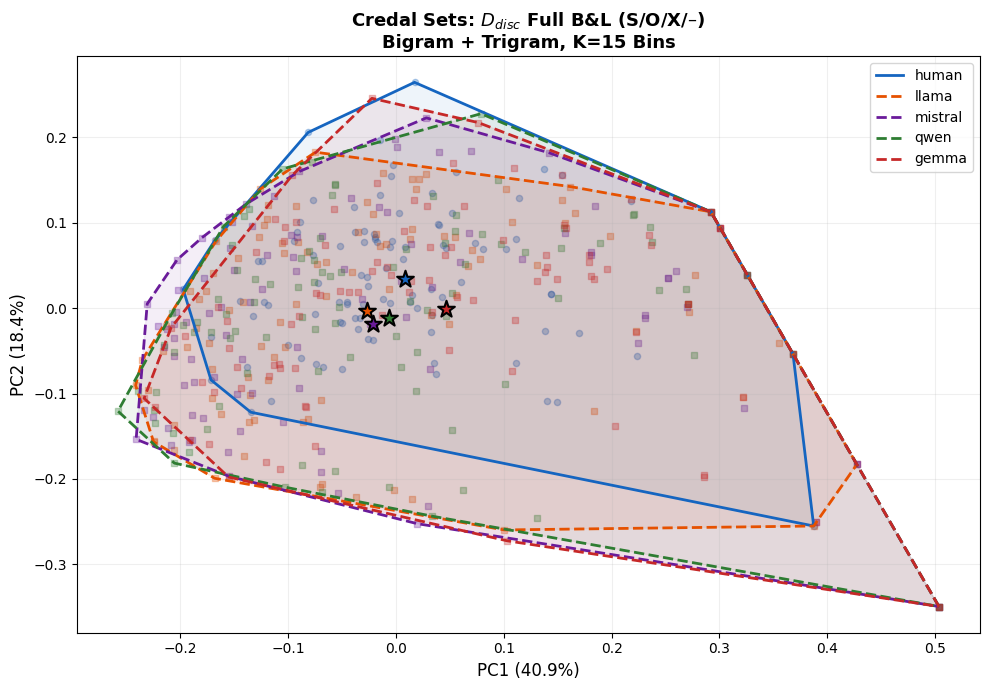

In [38]:
# Credal Sets: D_disc Full B&L

def pairwise_jsd_full_profiles(texts_list, alpha_trigram=0.3):
    """Compute pairwise JSD of combined bigram+trigram profiles for a list of texts"""
    profiles = []

    # Compute bigram and trigram profiles for each text
    for t in texts_list:
        bi, tri, _, _, _ = compute_transition_profile_full(t, use_trigrams=True)
        if tri is not None:
            combined = np.concatenate([(1 - alpha_trigram) * bi, alpha_trigram * tri])
        else:
            combined = bi
        profiles.append(combined)

    # Compute pairwise JSD for all unique pairs of combined profiles
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.array([jsd(profiles[i], profiles[j]) for i, j in pairs])

raw_dists_full = {}
t0 = time.time()

# Compute pairwise JSD profiles for all prompts and sources
for source in SOURCES:
    raw_dists_full[source] = [
        pairwise_jsd_full_profiles(texts[source][p]) for p in range(N_PROMPTS)
    ]
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')

# Transform raw distances to simplex points
all_raw_f = np.concatenate([np.concatenate(raw_dists_full[s]) for s in SOURCES])
sorted_ref_f = np.sort(all_raw_f)

def rank_transform_f(values):
    """Rank-transform distances to [0, 1] based on reference distribution"""
    return np.searchsorted(sorted_ref_f, values, side='right') / len(sorted_ref_f)

def dist_to_simplex_f(distances):
    """Convert raw distances to a smoothed histogram (simplex point)"""
    ranked = rank_transform_f(distances)
    counts, _ = np.histogram(ranked, bins=BIN_EDGES)
    smoothed = counts + ALPHA_SMOOTH
    return smoothed / smoothed.sum()

# Convert all raw distances to simplex points
simplex_full = {
    s: np.array([dist_to_simplex_f(raw_dists_full[s][p]) for p in range(N_PROMPTS)])
    for s in SOURCES
}

# Plot
all_sp_f = np.vstack([simplex_full[s] for s in SOURCES])
pca_disc_f = PCA(n_components=2).fit(all_sp_f)
d2d_f = {s: pca_disc_f.transform(simplex_full[s]) for s in SOURCES}

fig, ax = plt.subplots(figsize=(10, 7))
for source in SOURCES:
    pts = d2d_f[source]
    ls = '-' if source == 'human' else '--'
    marker = 'o' if source == 'human' else 's'
    ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source],
               alpha=0.3, s=20, marker=marker)
    centroid = pts.mean(axis=0)
    ax.scatter(*centroid, c=SOURCE_COLORS[source], s=160, marker='*',
               edgecolors='black', linewidth=1.5, zorder=6)
    try:
        hull = ConvexHull(pts)
        hull_idx = np.append(hull.vertices, hull.vertices[0])
        ax.fill(pts[hull.vertices, 0], pts[hull.vertices, 1],
                alpha=0.07, color=SOURCE_COLORS[source])
        ax.plot(pts[hull_idx, 0], pts[hull_idx, 1],
                color=SOURCE_COLORS[source], linewidth=2,
                linestyle=ls, label=source)
    except Exception:
        pass
ax.set_xlabel(f'PC1 ({pca_disc_f.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_disc_f.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Credal Sets: $D_{disc}$ Full B&L (S/O/X/–)\n'
             'Bigram + Trigram, K=15 Bins',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/credal_sets_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Control Analysis: Raw Values vs. Distances  for Full B&L

After feedback:
- The Human-vs-Model difference in $D_{\text{disc}}$ (Full B&L) could be an artifact of
the **distance computation** (mean pairwise JSD between entity-grid profiles) rather than a difference in
discourse structure
- JSD between distributions estimated from few counts is noisy
- Texts with fewer sentences/entities yield less stable profiles, which pushes pairwise JSD up systematically, independent of "true" structural diversity

Two checks:

1. **Raw, pooled transition profiles per source** (mean over all texts, no pairwise distance): shows whether the
   shape of the discourse structure actually differs between sources
2. **Confounding by text length / entity count**: tests whether $D_{\text{disc}}$ correlates with the number of
   sentences or usable entities (a sign of estimation noise rather than a genuine effect), and whether the
   Human-vs-Model gap survives after controlling for these

In [39]:
# Raw statistics: sentence count, entity count (total and used), transition profiles (bigram+trigram)
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression


def analyze_texts_full(texts_list, use_trigrams=False):
    """Profiles + raw statistics (sentence/entity count) for a list of texts (Full B&L model)"""
    # Initialize lists to store results
    profiles_bi, n_sents_l, n_ent_used_l, n_ent_total_l = [], [], [], []

    # Compute transition profiles and statistics for each text
    for t in texts_list:
        # Compute bigram and trigram profiles
        bi, _, grid, sents, entity_freq = compute_transition_profile_full(t, use_trigrams=use_trigrams)
        profiles_bi.append(bi)
        # Sentence count
        n_sents_l.append(len(sents))
        # Entity counts
        n_ent_total_l.append(len(entity_freq))
        # Count of entities used (frequency >= MIN_ENTITY_FREQ)
        n_ent_used_l.append(sum(1 for f in entity_freq.values() if f >= MIN_ENTITY_FREQ))
    return {
        'profiles_bi': np.array(profiles_bi),
        'n_sents': np.array(n_sents_l),
        'n_entities_total': np.array(n_ent_total_l),
        'n_entities_used': np.array(n_ent_used_l),
    }


raw_stats_full = {}
t0 = time.time()
for source in SOURCES:
    raw_stats_full[source] = [analyze_texts_full(texts[source][p]) for p in range(N_PROMPTS)]
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')
print(f'\nRaw statistics computed in {time.time()-t0:.0f}s')

  human   : done (128s)
  llama   : done (247s)
  mistral : done (379s)
  qwen    : done (477s)
  gemma   : done (562s)

Raw statistics computed in 562s


## Raw, pooled transition profiles per source

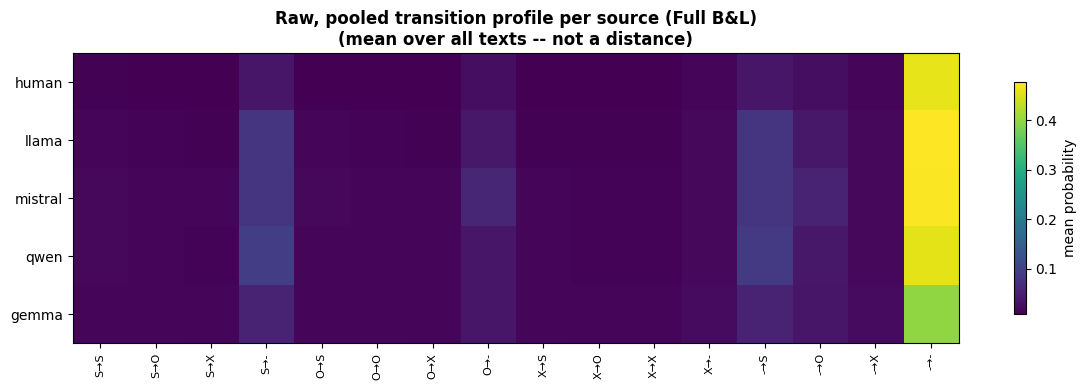

Source       H(mean profile)   D_disc (mean JSD)
------------------------------------------------
human                  2.132               0.225
llama                  2.510               0.151
mistral                2.692               0.124
qwen                   2.652               0.144
gemma                  2.755               0.165


In [40]:
# Pooled mean transition profile per source (across all prompts & texts)
mean_profile_full = {}
for source in SOURCES:
    all_profiles = np.vstack([raw_stats_full[source][p]['profiles_bi'] for p in range(N_PROMPTS)])
    mean_profile_full[source] = all_profiles.mean(axis=0)

# Heatmap: sources x 16 bigram transitions
fig, ax = plt.subplots(figsize=(12, 4))
mat = np.vstack([mean_profile_full[s] for s in SOURCES])
im = ax.imshow(mat, cmap='viridis', aspect='auto')
ax.set_yticks(range(len(SOURCES))); ax.set_yticklabels(SOURCES)
ax.set_xticks(range(N_BIGRAM))
ax.set_xticklabels([f'{a}\u2192{b}' for a, b in BIGRAM_TRANSITIONS], rotation=90, fontsize=8)
ax.set_title('Raw, pooled transition profile per source (Full B&L)\n(mean over all texts -- not a distance)',
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='mean probability')
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/raw_profile_heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()

# Entropy of the POOLED profile (= diversity of the "typical" structure, not a distance)
# vs. D_disc (mean pairwise JSD) -- shows whether both measures rank the sources the same way
print(f'{"Source":<10}{"H(mean profile)":>18}{"D_disc (mean JSD)":>20}')
print('-' * 48)
for source in SOURCES:
    h = entropy(mean_profile_full[source] + 1e-10, base=2)
    print(f'{source:<10}{h:>18.3f}{disc_scores_full[source].mean():>20.3f}')

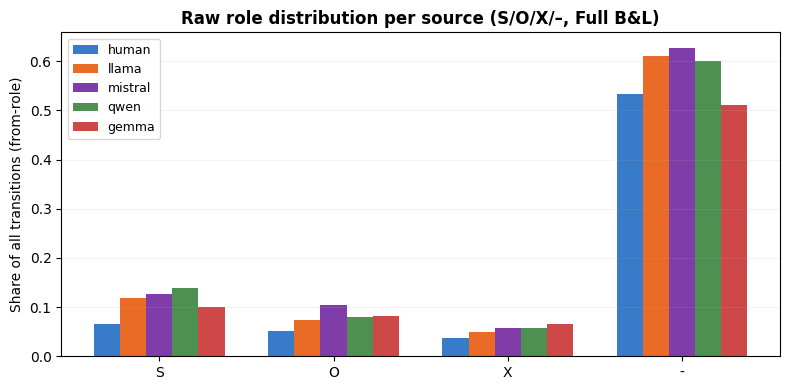

In [41]:
# Role occupancy (S/O/X/-) pooled per source (simplest "raw" summary)
role_occ_full = {}
for source in SOURCES:
    p = mean_profile_full[source].reshape(4, 4)  # rows = from-role, cols = to-role (order: ROLES)
    role_occ_full[source] = p.sum(axis=1)  # share of all transitions where an entity starts in this role

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(4)
width = 0.15
for j, source in enumerate(SOURCES):
    ax.bar(x + j * width, role_occ_full[source], width, label=source, color=SOURCE_COLORS[source], alpha=0.85)
ax.set_xticks(x + 2 * width); ax.set_xticklabels(ROLES)
ax.set_ylabel('Share of all transitions (from-role)')
ax.set_title('Raw role distribution per source (S/O/X/\u2013, Full B&L)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/raw_role_occupancy_full.png', dpi=150, bbox_inches='tight')
plt.show()

## Confounding by text length / entity count

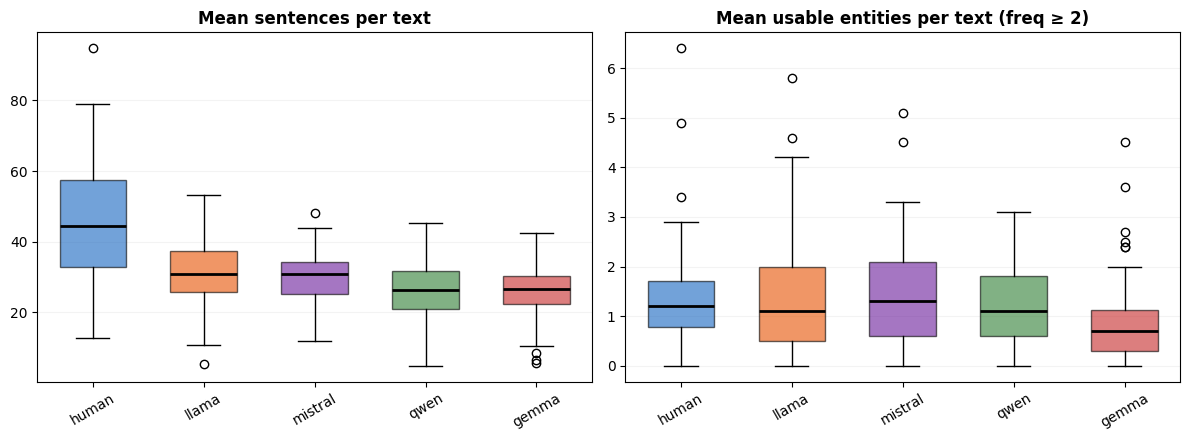

In [42]:
# Per-prompt averaged raw statistics (across the 10 texts of a source)
mean_n_sents_full = {s: np.array([raw_stats_full[s][p]['n_sents'].mean() for p in range(N_PROMPTS)]) for s in SOURCES}
mean_n_ent_used_full = {s: np.array([raw_stats_full[s][p]['n_entities_used'].mean() for p in range(N_PROMPTS)]) for s in SOURCES}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, data_dict, title in [
    (axes[0], mean_n_sents_full, 'Mean sentences per text'),
    (axes[1], mean_n_ent_used_full, f'Mean usable entities per text (freq \u2265 {MIN_ENTITY_FREQ})'),
]:
    data = [data_dict[s] for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True, widths=0.6,
                     medianprops=dict(color='black', linewidth=2))
    for patch, s in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[s]); patch.set_alpha(0.6)
    ax.set_title(title, fontweight='bold'); ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/confound_length_entities_full.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# Spearman correlation D_disc <-> confound variables, WITHIN each source (over 100 prompts)
# -> any correlation here can only come from noise/the distance computation
print('Spearman correlation D_disc <-> confound variables (per source, over 100 prompts)')
print(f'{"Source":<10}{"rho(n_sents)":>15}{"p":>10}{"rho(n_ent_used)":>18}{"p":>10}')
print('-' * 65)
for source in SOURCES:
    r1, p1 = spearmanr(mean_n_sents_full[source], disc_scores_full[source])
    r2, p2 = spearmanr(mean_n_ent_used_full[source], disc_scores_full[source])
    print(f'{source:<10}{r1:>15.3f}{p1:>10.3f}{r2:>18.3f}{p2:>10.3f}')

Spearman correlation D_disc <-> confound variables (per source, over 100 prompts)
Source       rho(n_sents)         p   rho(n_ent_used)         p
-----------------------------------------------------------------
human               0.106     0.296            -0.128     0.204
llama               0.023     0.822            -0.471     0.000
mistral             0.023     0.821            -0.341     0.001
qwen                0.031     0.757            -0.253     0.011
gemma               0.015     0.886             0.008     0.940


In [44]:
# Does the Human-vs-Model gap in D_disc survive after controlling for sentence/entity count?
rows = []
for source in SOURCES:
    for p in range(N_PROMPTS):
        rows.append({
            'source': source,
            'is_human': int(source == 'human'),
            'D_disc': disc_scores_full[source][p],
            'n_sents': mean_n_sents_full[source][p],
            'n_ent_used': mean_n_ent_used_full[source][p],
        })
df_confound_full = pd.DataFrame(rows)

# Linear regression: D_disc ~ is_human (+ confounds)
y = df_confound_full['D_disc'].values
X_raw = df_confound_full[['is_human']].values
X_ctrl = df_confound_full[['is_human', 'n_sents', 'n_ent_used']].values

m_raw = LinearRegression().fit(X_raw, y)
m_ctrl = LinearRegression().fit(X_ctrl, y)

print('Without control (matches the boxplot and Cohen\'s d above):')
print(f"  is_human coefficient: {m_raw.coef_[0]:+.4f}   (R\u00b2={m_raw.score(X_raw, y):.3f})")
print()
print('With control for sentence/entity count:')
print(f"  is_human coefficient:   {m_ctrl.coef_[0]:+.4f}   (R\u00b2={m_ctrl.score(X_ctrl, y):.3f})")
print(f"  n_sents coefficient:    {m_ctrl.coef_[1]:+.4f}")
print(f"  n_ent_used coefficient: {m_ctrl.coef_[2]:+.4f}")
print()
print(f"  Share of the is_human effect remaining after control: "
      f"{m_ctrl.coef_[0] / m_raw.coef_[0] * 100:.0f}%")

Without control (matches the boxplot and Cohen's d above):
  is_human coefficient: +0.0786   (R²=0.115)

With control for sentence/entity count:
  is_human coefficient:   +0.0576   (R²=0.237)
  n_sents coefficient:    +0.0015
  n_ent_used coefficient: -0.0341

  Share of the is_human effect remaining after control: 73%


# 4. Entity-Frequency Filter (MIN_ENTITY_FREQ)

- Entity-frequency filter (`MIN_ENTITY_FREQ = 2`) drops entities that appear in only one sentence before the bigram/trigram counts are built 
- Motivated by Barzilay & Lapata's "salience" concept — single mentions mostly just add `-` transitions
- But the profile is already salience-weighted via `log(1 + freq)`, which softly down-weights rare entities  
-> Hard cutoff may be partly redundant with the weighting
- Plausible driver of the sparsity problem found in Section 3 (median: 1 usable entity per text at `MIN_ENTITY_FREQ = 2`).

Checking:

1. Does usable-entity count per text increase as the filter is loosened (as expected)?
2. Does the sparsity artifact from Section 3 (correlation between $D_{\text{disc}}$ and entity count) shrink?
3. Does discrimination between Human and Model survive across thresholds?

In [45]:
# Cache entity grids for all texts and prompts, so that we can reuse them later without re-parsing

t0 = time.time()
cached_grids = {}
for source in SOURCES:
    cached_grids[source] = [
        [build_entity_grid_full(t) for t in texts[source][p]] for p in range(N_PROMPTS)
    ]
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')
print(f'\nEntity grids cached in {time.time()-t0:.0f}s')

  human   : done (128s)
  llama   : done (235s)
  mistral : done (347s)
  qwen    : done (432s)
  gemma   : done (508s)

Entity grids cached in 508s


In [46]:
# Filtering for different MIN_ENTITY_FREQ thresholds

def profile_from_grid(grid, entity_freq, min_freq, use_trigrams=True):
    """Bigram/trigram profile from a pre-built entity grid, for a given MIN_ENTITY_FREQ threshold."""
    if not grid:
        return (np.ones(N_BIGRAM) / N_BIGRAM,
                np.ones(N_TRIGRAM) / N_TRIGRAM if use_trigrams else None, 0)
    
    bigram_counts, trigram_counts = Counter(), Counter()
    n_used = 0

    # Count weighted bigram/trigram transitions for entities that meet the frequency threshold
    for entity, roles_seq in grid.items():
        if entity_freq[entity] < min_freq:
            continue
        n_used += 1

        # Weight transitions by the log of the entity's frequency to emphasize more salient entities
        weight = np.log(1 + entity_freq[entity])

        for k in range(len(roles_seq) - 1):
            bigram_counts[(roles_seq[k], roles_seq[k+1])] += weight

        # Count trigrams if enabled and if the entity has enough roles
        if use_trigrams and len(roles_seq) >= 3:
            for k in range(len(roles_seq) - 2):
                trigram_counts[(roles_seq[k], roles_seq[k+1], roles_seq[k+2])] += weight
    
    bigram_total = sum(bigram_counts.values()) or 1
    bigram_profile = np.array([bigram_counts[t] / bigram_total for t in BIGRAM_TRANSITIONS])
    trigram_profile = None
    if use_trigrams:
        trigram_total = sum(trigram_counts.values()) or 1
        trigram_profile = np.array([trigram_counts[t] / trigram_total for t in TRIGRAM_TRANSITIONS])
    return bigram_profile, trigram_profile, n_used


def discourse_diversity_from_cache(prompt_grids, min_freq, use_trigrams=True, alpha_trigram=0.3):
    """D_disc for one prompt's cached grids, at a given MIN_ENTITY_FREQ threshold."""
    profiles_bi, profiles_tri, n_used_list = [], [], []

    # Compute bigram/trigram profiles for each text in the prompt
    for grid, sents, entity_freq in prompt_grids:
        bi, tri, n_used = profile_from_grid(grid, entity_freq, min_freq, use_trigrams=use_trigrams)
        profiles_bi.append(bi)
        if tri is not None:
            profiles_tri.append(tri)
        n_used_list.append(n_used)
    
    # Compute pairwise JSD for bigram profiles
    profiles_bi = np.array(profiles_bi)
    pairs = list(combinations(range(len(prompt_grids)), 2))
    jsd_bi = np.mean([jsd(profiles_bi[i], profiles_bi[j]) for i, j in pairs])
    if use_trigrams and profiles_tri:
        profiles_tri = np.array(profiles_tri)
        jsd_tri = np.mean([jsd(profiles_tri[i], profiles_tri[j]) for i, j in pairs])
        d = (1 - alpha_trigram) * jsd_bi + alpha_trigram * jsd_tri
    else:
        d = jsd_bi
    return d, np.mean(n_used_list)


MIN_FREQS = [1, 2, 3]
disc_scores_mf = {mf: {} for mf in MIN_FREQS}
mean_n_used_mf = {mf: {} for mf in MIN_FREQS}

for mf in MIN_FREQS:
    for source in SOURCES:
        d_scores, n_used = [], []
        for p in range(N_PROMPTS):
            d, nu = discourse_diversity_from_cache(cached_grids[source][p], mf, use_trigrams=True, alpha_trigram=0.3)
            d_scores.append(d)
            n_used.append(nu)
        disc_scores_mf[mf][source] = np.array(d_scores)
        mean_n_used_mf[mf][source] = np.array(n_used)
    print(f'MIN_ENTITY_FREQ={mf}: done')

MIN_ENTITY_FREQ=1: done
MIN_ENTITY_FREQ=2: done
MIN_ENTITY_FREQ=3: done


## Does loosening the filter actually add usable entities?

In [47]:
print(f'{"MIN_ENTITY_FREQ":<18}', end='')
for s in SOURCES: print(f'{s:>10}', end='')
print()
print('-' * (18 + 10 * len(SOURCES)))
for mf in MIN_FREQS:
    print(f'{mf:<18}', end='')
    for s in SOURCES:
        print(f'{np.median(mean_n_used_mf[mf][s]):>10.2f}', end='')
    print()
print('\n(median usable entities per text, i.e. entities with freq >= MIN_ENTITY_FREQ)')

MIN_ENTITY_FREQ        human     llama   mistral      qwen     gemma
--------------------------------------------------------------------
1                       4.75      2.25      1.80      1.89      1.50
2                       1.20      1.10      1.30      1.10      0.70
3                       0.70      0.80      1.00      0.70      0.30

(median usable entities per text, i.e. entities with freq >= MIN_ENTITY_FREQ)


## Does the sparsity artifact (Section 3) shrink

In [49]:
print('Spearman rho(D_disc, n_entities_used) within source, by MIN_ENTITY_FREQ')
for mf in MIN_FREQS:
    print(f'MIN_ENTITY_FREQ = {mf}')
    for source in SOURCES:
        r, p_ = spearmanr(mean_n_used_mf[mf][source], disc_scores_mf[mf][source])
        sig = '*' if p_ < 0.05 else ' '
        print(f'  {source:<10} rho={r:+.3f}  p={p_:.3f} {sig}')
    print()

Spearman rho(D_disc, n_entities_used) within source, by MIN_ENTITY_FREQ
MIN_ENTITY_FREQ = 1
  human      rho=-0.649  p=0.000 *
  llama      rho=-0.823  p=0.000 *
  mistral    rho=-0.705  p=0.000 *
  qwen       rho=-0.699  p=0.000 *
  gemma      rho=-0.791  p=0.000 *

MIN_ENTITY_FREQ = 2
  human      rho=-0.128  p=0.204  
  llama      rho=-0.471  p=0.000 *
  mistral    rho=-0.341  p=0.001 *
  qwen       rho=-0.253  p=0.011 *
  gemma      rho=+0.008  p=0.940  

MIN_ENTITY_FREQ = 3
  human      rho=+0.513  p=0.000 *
  llama      rho=-0.099  p=0.326  
  mistral    rho=-0.131  p=0.193  
  qwen       rho=+0.032  p=0.749  
  gemma      rho=+0.556  p=0.000 *



##  Does Human-vs-Model discrimination survive?

In [50]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std()**2 + (nb - 1) * b.std()**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0


print(f'{"MIN_ENTITY_FREQ":<18}{"is_human coef":>15}{"R2":>8}{"Cohen d (H vs models)":>24}')
print('-' * 65)
for mf in MIN_FREQS:
    rows = []
    for source in SOURCES:
        for p in range(N_PROMPTS):
            rows.append({'is_human': int(source == 'human'), 'D_disc': disc_scores_mf[mf][source][p]})
    df_mf = pd.DataFrame(rows)
    X = df_mf[['is_human']].values
    y = df_mf['D_disc'].values
    m = LinearRegression().fit(X, y)

    h = disc_scores_mf[mf]['human']
    all_models = np.concatenate([disc_scores_mf[mf][s] for s in SOURCES if s != 'human'])
    d = cohens_d(h, all_models)

    print(f'{mf:<18}{m.coef_[0]:>+15.4f}{m.score(X, y):>8.3f}{d:>24.3f}')

MIN_ENTITY_FREQ     is_human coef      R2   Cohen d (H vs models)
-----------------------------------------------------------------
1                         -0.0073   0.001                  -0.077
2                         +0.0786   0.115                   0.901
3                         +0.0686   0.093                   0.803


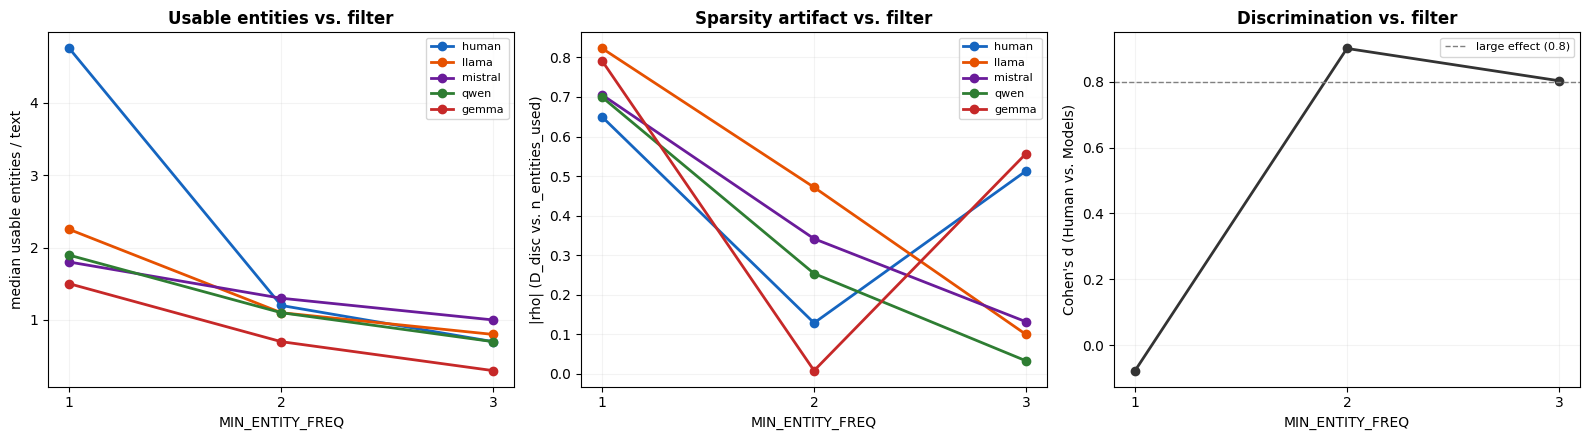

: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: median usable entities by threshold
ax = axes[0]
for s in SOURCES:
    ax.plot(MIN_FREQS, [np.median(mean_n_used_mf[mf][s]) for mf in MIN_FREQS],
            'o-', color=SOURCE_COLORS[s], label=s, linewidth=2)
ax.set_xlabel('MIN_ENTITY_FREQ'); ax.set_ylabel('median usable entities / text')
ax.set_title('Usable entities vs. filter', fontweight='bold')
ax.set_xticks(MIN_FREQS)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.15)

# Panel 2: sparsity correlation magnitude by threshold
ax = axes[1]
for s in SOURCES:
    rhos = [abs(spearmanr(mean_n_used_mf[mf][s], disc_scores_mf[mf][s])[0]) for mf in MIN_FREQS]
    ax.plot(MIN_FREQS, rhos, 'o-', color=SOURCE_COLORS[s], label=s, linewidth=2)
ax.set_xlabel('MIN_ENTITY_FREQ'); ax.set_ylabel('|rho| (D_disc vs. n_entities_used)')
ax.set_title('Sparsity artifact vs. filter', fontweight='bold')
ax.set_xticks(MIN_FREQS)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.15)

# Panel 3: discrimination (Cohen's d) by threshold
ax = axes[2]
ds = []
for mf in MIN_FREQS:
    h = disc_scores_mf[mf]['human']
    all_models = np.concatenate([disc_scores_mf[mf][s] for s in SOURCES if s != 'human'])
    ds.append(cohens_d(h, all_models))
ax.plot(MIN_FREQS, ds, 'o-', color='#333333', linewidth=2)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, label='large effect (0.8)')
ax.set_xlabel('MIN_ENTITY_FREQ'); ax.set_ylabel("Cohen's d (Human vs. Models)")
ax.set_title('Discrimination vs. filter', fontweight='bold')
ax.set_xticks(MIN_FREQS)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('../../figures/discourse_diversity/ablation_min_entity_freq.png', dpi=150, bbox_inches='tight')
plt.show()